# Exporation of mhd_ch4_formatted_v1.csv 

df_mhd_ch4_raw : raw data

df_mhd_ch4_v1: one-hot flags

df_mhd_ch4_v2: a copy of df_mhd_ch4_v1

df_mhd_ch4_v3:drop the feature contains almost all are nan values

df_mhd_ch4_drop: drop extreme values from psamp and pflow


In [1]:
import seaborn as sns
sns.set_theme(style='darkgrid')

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

# read data files
df_mhd_ch4_raw = pd.read_csv("../data/processed/mhd_ch4_formatted_v1.csv")
df_mhd_ch4_raw.head(20)


/tmp/ipykernel_45859/4231044995.py:6: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mhd_ch4_raw = pd.read_csv("../data/processed/mhd_ch4_formatted_v1.csv")


,date,time,type,sample,standard,port,ht,tmod,tamb,temp,...,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,NaN,NaN,NaN,NaN
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN


In [3]:
df_mhd_ch4_raw.iloc[[-1]]

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,...,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
817954,260518,81300,std,J-286,J-286,3,0,40.0,22.23,NaN,...,NaN,NaN,NaN,14.873,NaN,2015.923,NaN,NaN,A,NaN


In [4]:
df_mhd_ch4_raw.iloc[[11123]]

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,...,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
11123,940802,114700,std,G-028,G-028,1,0,40.0,23.89,NaN,...,1671.33,1672.89,1671.33,2.264,NaN,1672.724,NaN,NaN,NaN,NaN


In [5]:
print(df_mhd_ch4_raw['ploop']-(df_mhd_ch4_raw['ploop'].isnull()))

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
817950   NaN
817951   NaN
817952   NaN
817953   NaN
817954   NaN
Name: ploop, Length: 817955, dtype: float64


In [6]:
df_mhd_ch4_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817955 entries, 0 to 817954
Data columns (total 42 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             817955 non-null  int64  
 1   time             817955 non-null  int64  
 2   type             817954 non-null  object 
 3   sample           817955 non-null  object 
 4   standard         817955 non-null  object 
 5   port             817955 non-null  int64  
 6   ht               817955 non-null  int64  
 7   tmod             705671 non-null  float64
 8   tamb             705671 non-null  float64
 9   temp             0 non-null       float64
 10  pflow            815553 non-null  float64
 11  psamp            815626 non-null  float64
 12  ploop            0 non-null       float64
 13  pamb             815551 non-null  float64
 14  rt               816365 non-null  float64
 15  w                816365 non-null  float64
 16  CH4_ht.1         816365 non-null  floa

 9   temp             1 non-null       float64
12  ploop            1 non-null       float64
 41  CH4_flag_p       0 non-null       float64

 ----------
 almost all Nan
 maybe no use for training ml model

In [7]:
string_list = ['type', 'sample', 'standard', 'CH4_flag_ht', 'CH4_flag_a', 'CH4_flag']
for i in string_list:
    print(f"{i} values including:,{df_mhd_ch4_raw[i].value_counts()}", "\n")

type values including:,type
std        414114
air        372609
tank        15952
cal560       2616
cal660       2609
cal860       2607
cal960       2603
cal1060      2595
cal           987
labair        653
blank         521
cal150         12
tank100         6
cal225          6
cal30           6
cal120          6
cal60           6
cal180          6
cal300          6
cal90           6
cal45           4
cal15           3
cal135          3
cal75           3
cal105          3
cal200          3
cal165          3
cal250          3
cal500          3
Name: count, dtype: int64 

sample values including:,sample
10m       335171
9m         34964
J-273      12205
J-254      11469
J-231      11315
           ...  
990619         1
990631         1
990628         1
990633         1
H-313          1
Name: count, Length: 515, dtype: int64 

standard values including:,standard
J-273       24266
J-254       22463
J-231       22202
J-197       21469
J-223       21298
J-206       21233
J-144       21048


/tmp/ipykernel_45859/1842129789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_45859/1842129789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_45859/1842129789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_45859/1842129789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_45859/1842129789.py:9: FutureWarn

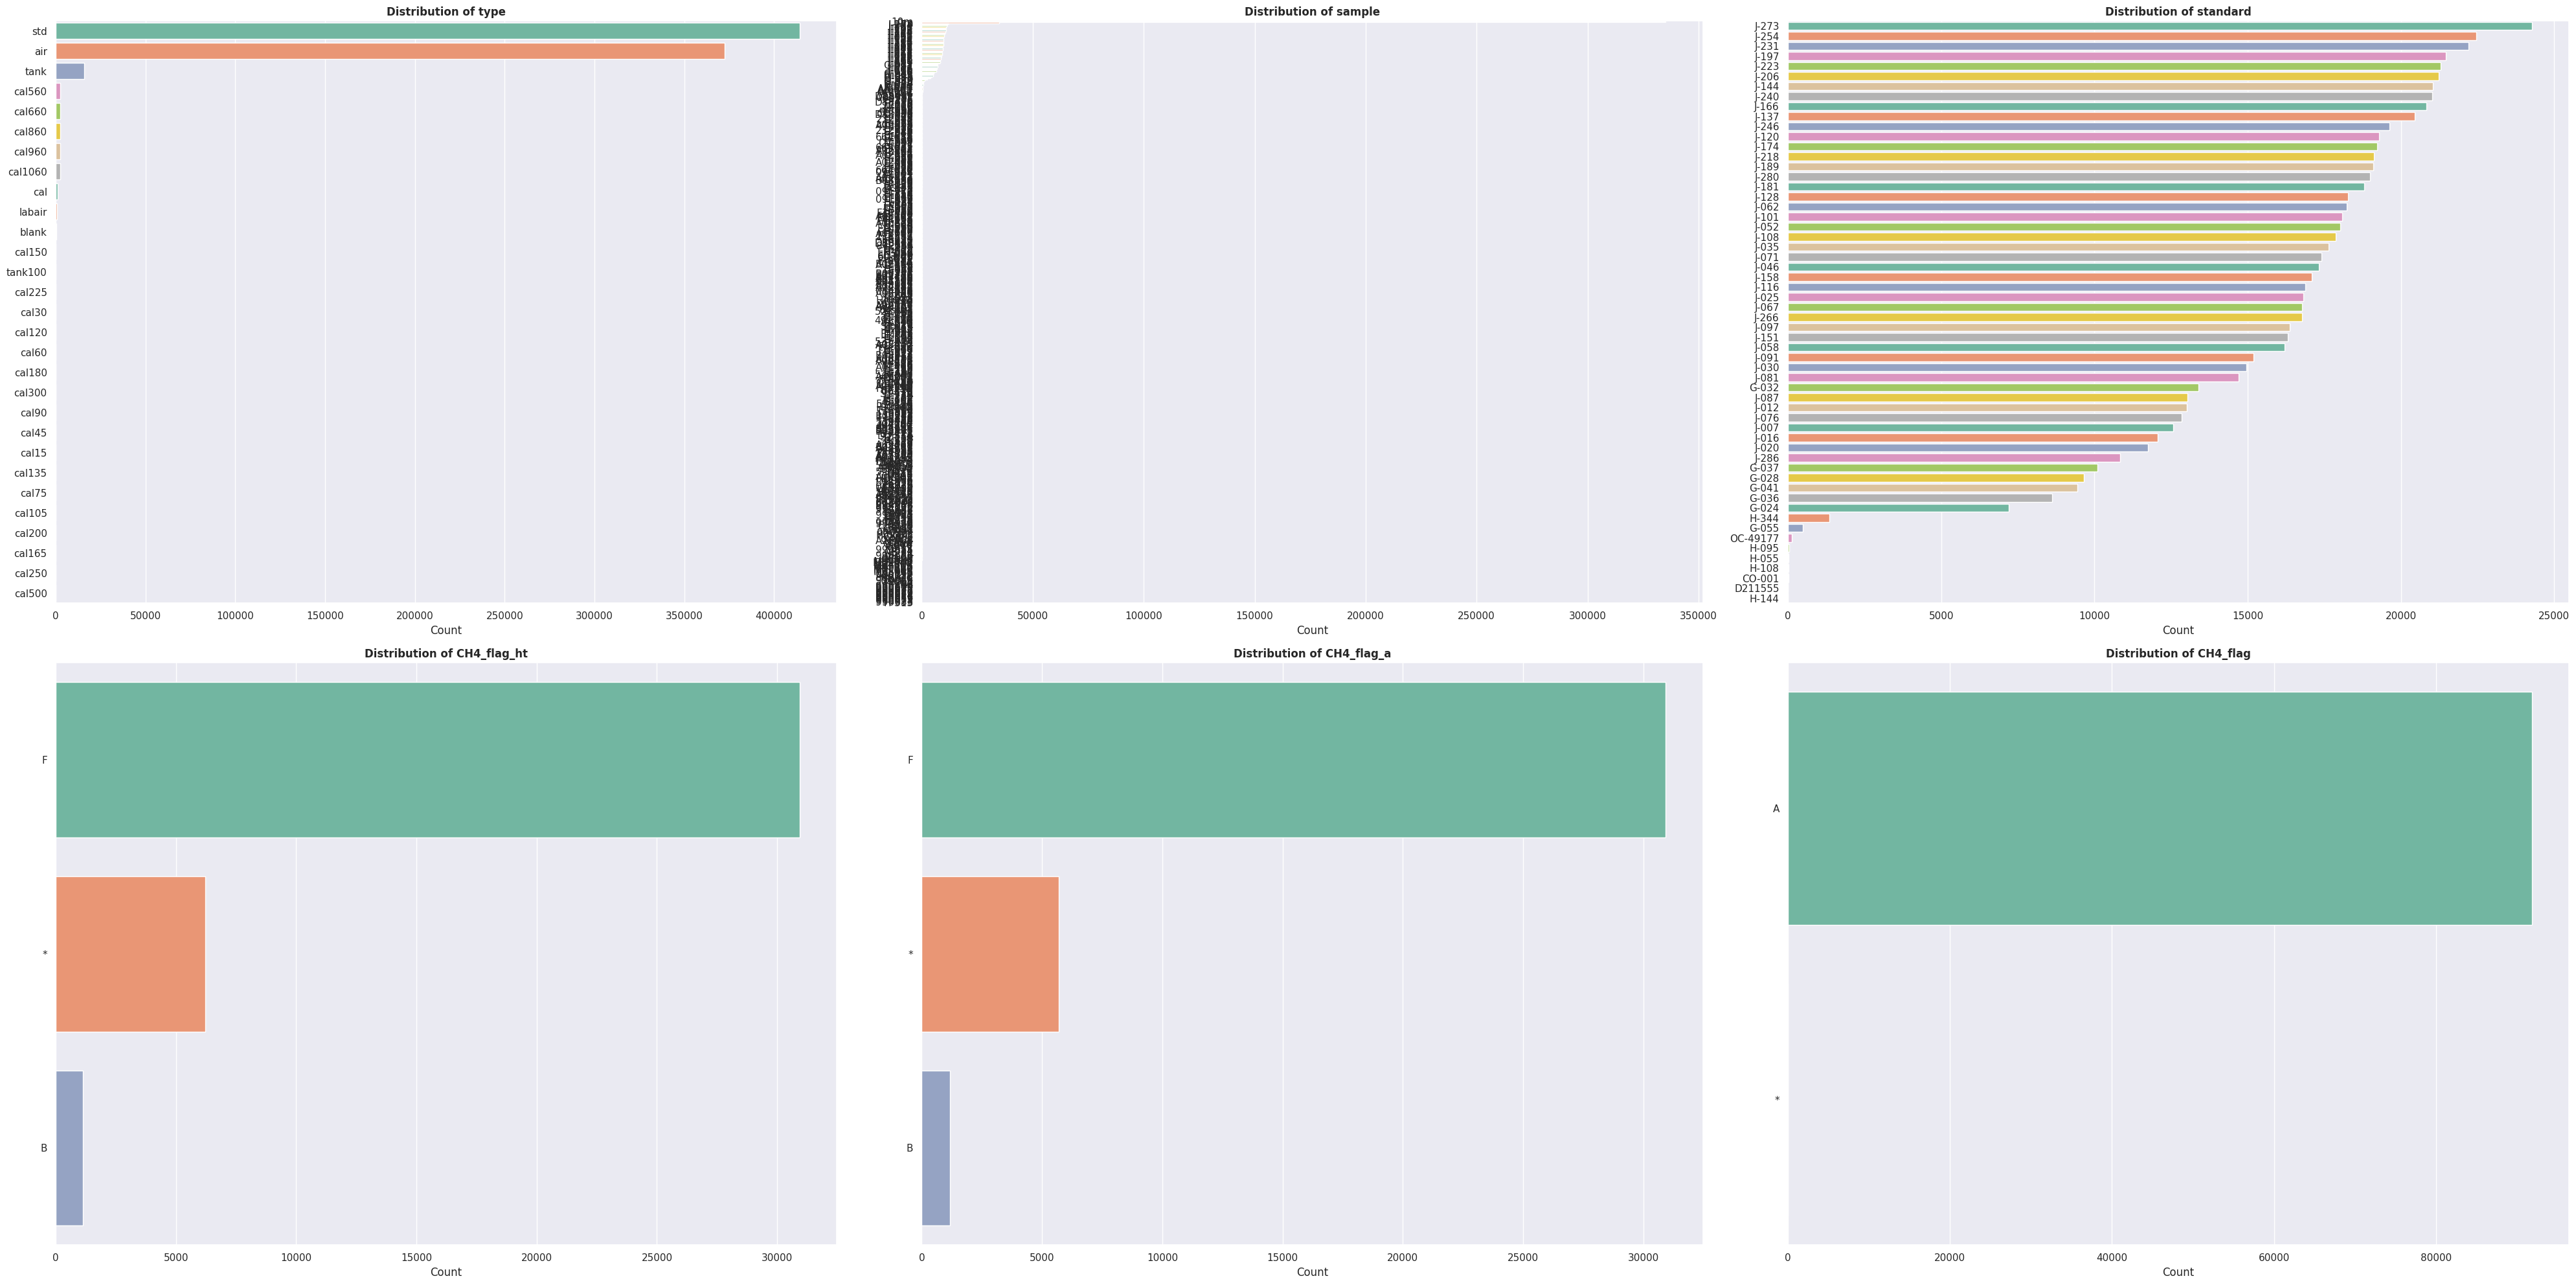

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2,3, figsize=(40, 20))

axes = axes.flatten()

for i, col in enumerate(string_list):
    if col in df_mhd_ch4_raw.columns:
        sns.countplot(
            data=df_mhd_ch4_raw,
            y=col,
            ax=axes[i],
            order = df_mhd_ch4_raw[col].value_counts().index,
            palette='Set2'
        )
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Count')
        axes[i].set_ylabel('')

    else:
        axes[i].set_title(f'{col} (Not Found)')

plt.tight_layout()
plt.show()

The distribution plot of sample is too narrow
-> make it bigger to explore it

/tmp/ipykernel_45859/1873865919.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


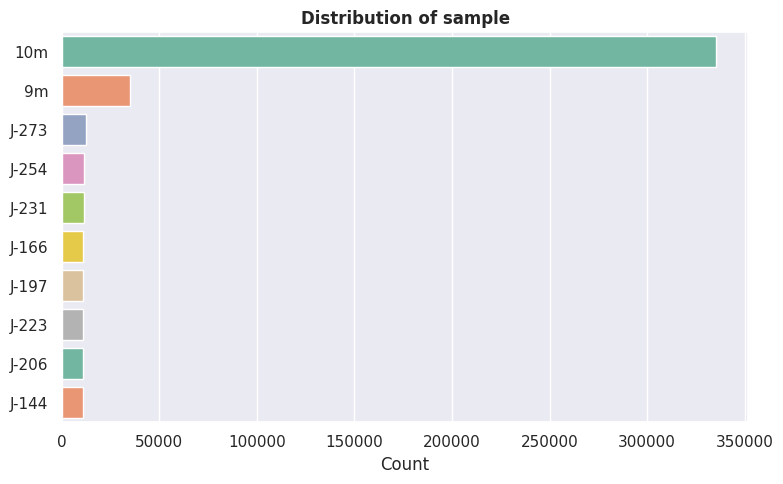

In [9]:
fig, axes = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=df_mhd_ch4_raw,
    y='sample',
    order = df_mhd_ch4_raw['sample'].value_counts().index[:10],
    palette='Set2'
)
axes.set_title(f'Distribution of sample', fontsize=12, fontweight='bold')
axes.set_xlabel('Count')
axes.set_ylabel('')

plt.tight_layout()
plt.show()

====== 0523 ends =======

=============== 0525 starts==============

0526 feature engineering
create new feature: label( show whether good or bad data)

In [10]:
df_mhd_ch4_v1 =df_mhd_ch4_raw.copy()

In [11]:
# convert nan values into " "(space)-> means good values
mapping={" ":0, 
          "x":1, 
          "*":1,
          "F":1, 
          "B":1, 
          "A":1
        }
df_mhd_ch4_v1 ["CH4_flag"] = df_mhd_ch4_v1 ["CH4_flag"].fillna(" ")
df_mhd_ch4_v1 ["CH4_flag_ht"] = df_mhd_ch4_v1 ["CH4_flag_ht"].fillna(" ")
df_mhd_ch4_v1 ["CH4_flag_a"] = df_mhd_ch4_v1 ["CH4_flag_a"].fillna(" ")

In [12]:
# convert flag to 0/1
df_mhd_ch4_v1 ["CH4_flag_ht"] = df_mhd_ch4_v1 ["CH4_flag_ht"].map(mapping)
df_mhd_ch4_v1 ["CH4_flag_a"] = df_mhd_ch4_v1 ["CH4_flag_a"].map(mapping)


In [13]:
df_mhd_ch4_v1 ['label'] = ((df_mhd_ch4_v1 ["CH4_flag_ht"]==1) | (df_mhd_ch4_v1 ["CH4_flag_a"]==1)).astype(int)
df_mhd_ch4_v1 ['label']

0         1
1         1
2         1
3         0
4         1
         ..
817950    0
817951    0
817952    0
817953    1
817954    0
Name: label, Length: 817955, dtype: int64

In [14]:
df_mhd_ch4_v1["CH4_flag"] 

0          
1          
2          
3          
4          
         ..
817950    A
817951    A
817952    A
817953    A
817954    A
Name: CH4_flag, Length: 817955, dtype: object

In [15]:
df_mhd_ch4_v2 = df_mhd_ch4_v1.copy()

df_mhd_ch4_v2

In [16]:
pd.set_option('display.max_columns', None)
df_mhd_ch4_v2.iloc[[185]]

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,label
185,940219,102700,cal1060,G-024,G-024,1,0,40.01,23.16,NaN,846.8,1058.3,NaN,751.2,95.2,7.51,205489.0,1651923.0,1.0,82.6,130.2,30872.0,30727.0,0.92736,1.00177,0.92736,1.3073,1.4122,1.0901,0.92736,1.00177,0.92736,1569.54,1695.49,1692.49,3.18,NaN,1692.489,0,0,,NaN,0


In [17]:
df_mhd_ch4_v2.iloc[[-1]]

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,label
817954,260518,81300,std,J-286,J-286,3,0,40.0,22.23,NaN,813.3,752.09,NaN,752.0,82.0,5.46,204547.0,1177596.0,0.43,73.0,115.2,75876.0,68601.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.873,NaN,2015.923,0,0,A,NaN,0


df_mhd_ch4[''].corr()

 0526 dataset checked no error 

In [18]:
df_mhd_ch4_v2.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,label
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,0,0,,NaN,0
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1


In [19]:
df_mhd_ch4_v2.isna().sum().sort_values(ascending=False)

temp               817955
CH4_flag_p         817955
ploop              817955
CH4_std_rep        471914
tmod               112284
tamb               112284
CH4_C               59835
CH4_Rl              58674
CH4_R               58674
CH4_C_ht            52743
CH4_Rl_ht           51247
CH4_norm_a          51247
CH4_norm_w          51247
CH4_R_ht            51247
CH4_norm_ht         51247
CH4_C_a             50993
CH4_Rl_a            49492
CH4_R_a             49492
CH4_std_stdev       21816
pamb                 2404
pflow                2402
psamp                2329
CH4_start_time       1590
w                    1590
CH4_ht.1             1590
CH4_area             1590
CH4_end_level        1590
rt                   1590
CH4_end_time         1590
CH4_start_level      1590
CH4_skew             1590
type                    1
time                    0
date                    0
ht                      0
sample                  0
standard                0
port                    0
CH4_Cstd    

define which features sould quite( too much nan)

**Remove the Nan values (that almost all Nan)** 

In [20]:
cols_to_drop=['temp','CH4_flag_p','ploop','CH4_flag' ]
df_mhd_ch4_v3 = df_mhd_ch4_v2.drop(columns=cols_to_drop)

df_mhd_ch4_v3

In [21]:
df_mhd_ch4_v3.isna().sum().sort_values(ascending=False)

CH4_std_rep        471914
tmod               112284
tamb               112284
CH4_C               59835
CH4_R               58674
CH4_Rl              58674
CH4_C_ht            52743
CH4_norm_ht         51247
CH4_norm_w          51247
CH4_norm_a          51247
CH4_R_ht            51247
CH4_Rl_ht           51247
CH4_C_a             50993
CH4_Rl_a            49492
CH4_R_a             49492
CH4_std_stdev       21816
pamb                 2404
pflow                2402
psamp                2329
CH4_skew             1590
CH4_area             1590
w                    1590
CH4_start_level      1590
rt                   1590
CH4_end_level        1590
CH4_start_time       1590
CH4_end_time         1590
CH4_ht.1             1590
type                    1
time                    0
date                    0
ht                      0
port                    0
standard                0
sample                  0
CH4_Cstd                0
CH4_flag_ht             0
CH4_flag_a              0
label       

In [22]:
df_mhd_ch4_v3['type'].value_counts()

type
std        414114
air        372609
tank        15952
cal560       2616
cal660       2609
cal860       2607
cal960       2603
cal1060      2595
cal           987
labair        653
blank         521
cal150         12
tank100         6
cal225          6
cal30           6
cal120          6
cal60           6
cal180          6
cal300          6
cal90           6
cal45           4
cal15           3
cal135          3
cal75           3
cal105          3
cal200          3
cal165          3
cal250          3
cal500          3
Name: count, dtype: int64

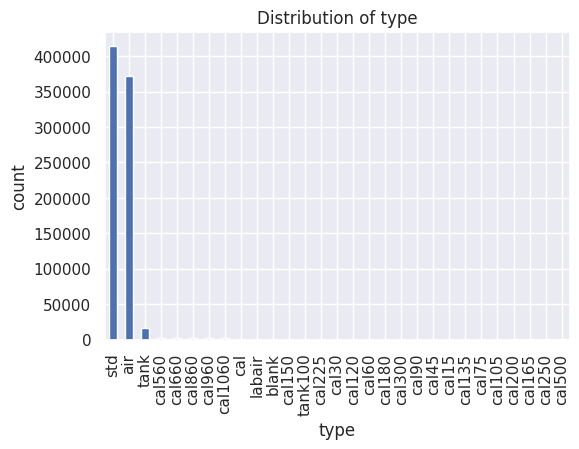

In [23]:
import matplotlib.pyplot as plt 
df_mhd_ch4_v3['type'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Distribution of type")
plt.xlabel('type')
plt.ylabel('count')
plt.show()

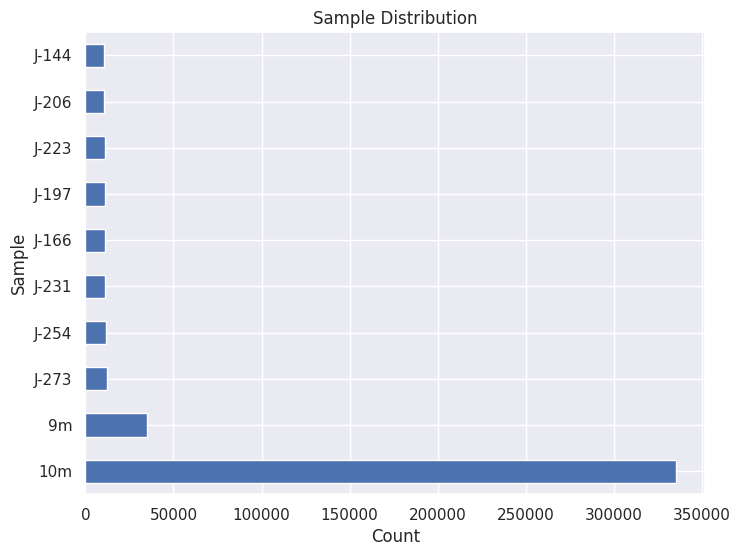

In [24]:
import matplotlib.pyplot as plt 
df_mhd_ch4_v3['sample'].value_counts().head(10).plot(
    kind='barh',
    figsize=(8,6)
)
plt.title("Sample Distribution")
plt.xlabel('Count')
plt.ylabel('Sample')
plt.show()
# too many -> only show first 10
#===================
# 10m, 9m -> air
# other-> std, cal

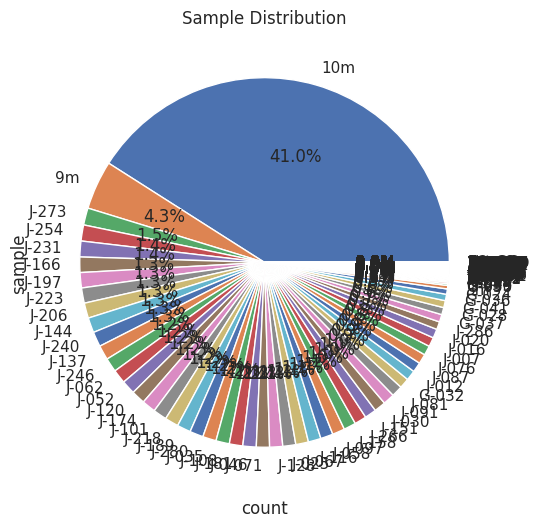

In [25]:
df_mhd_ch4_v3['sample'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Sample Distribution')
plt.xlabel('count')
plt.ylabel('sample')
plt.show()

The pie chart show that the 10m and 9m accounts most data
-> 10m, 9m means -> air

In [26]:
pd.set_option('display.max_rows', None)
df_mhd_ch4_v3['sample'].value_counts()

sample
10m       335171
9m         34964
J-273      12205
J-254      11469
J-231      11315
J-166      11009
J-197      10937
J-223      10877
J-206      10854
J-144      10735
J-240      10665
J-137      10426
J-246      10029
J-062       9962
J-052       9915
J-120       9850
J-174       9825
J-101       9771
J-218       9768
J-189       9760
J-280       9692
J-035       9662
J-108       9609
J-181       9603
J-046       9550
J-071       9416
J-128       9336
J-025       9260
J-067       9078
J-116       9078
J-058       8931
J-097       8871
J-158       8699
J-266       8552
J-151       8323
J-030       8229
J-091       8217
J-081       7916
G-032       7182
J-012       7166
J-087       7064
J-076       6944
J-007       6790
J-016       6613
J-020       6449
J-286       5573
G-037       5375
G-028       5112
G-041       5014
G-036       4571
G-024       3811
3m          2465
G-050       1181
G-055       1132
H-344        726
H-054        719
H-055        605
labair       534
H-095  

type ->  std and correponding sample

In [27]:
df_mhd_ch4_v3.loc[df_mhd_ch4_v3['type']=='std', 'sample'].unique()

array(['G-024', 'G-028', 'G-032', 'CO-001', 'G-036', 'G-037', 'G-041',
       'J-007', 'J-012', 'J-016', 'J-020', 'J-025', 'J-030', 'J-035',
       'J-046', 'J-052', 'J-058', 'J-062', 'J-067', 'J-071', 'J-076',
       'J-081', 'J-087', 'J-091', 'J-097', 'J-101', '-49177', 'J-108',
       'J-116', 'H-108', 'J-120', 'H-144', 'J-128', 'J-137', 'J-144',
       'G-055', 'J-151', 'J-158', 'J-166', 'J-174', 'J-181', 'J-189',
       'J-197', 'H-095', 'J-206', 'H-344', 'J-218', 'J-223', 'J-231',
       'J-240', 'J-246', 'J-254', 'J-266', 'J-273', 'H-055', '211555',
       'J-280', 'J-286'], dtype=object)

type ->  air and correponding sample

In [28]:
df_mhd_ch4_v3.loc[df_mhd_ch4_v3['type']=='air', 'sample'].unique()

array(['10m', '158E-p', 'Sib1_4', '3m', '9m'], dtype=object)

type ->  tank and correponding sample

In [29]:
df_mhd_ch4_v3.loc[df_mhd_ch4_v3['type']=='tank', 'sample'].unique()


array(['-49177', 'G-024', 'S-003', 'G-032', 'S-004', 'H-005', 'H-004',
       'H-006D', 'H-006', 'MRF-S', 'MRF-D', 'H-003', 'CO-001', '005557',
       'G-036', '49177D', 'O-001D', 'G-037', 'H-007', '60-H09', '60-H05',
       'FD-005', 'H-008D', 'H-008', 'G-041', 'CO1', 'J-007', 'H-009',
       'M-001', 'M-002', 'H-009D', 'H-010', 'H-011', 'J-012', 'M-005',
       '.Leeds', 'J-016', 'H-012', 'Bris1', 'G-050', 'G-055', 'H-013',
       'H-014', 'M-006', 'B-003', 'M-007', 'J-020', 'H-015', 'BRW1',
       '064959', 'HD-007', '-007-6', '-007-4', '-007-3', '-007-2',
       'J-025', 'H-016', 'A01469', 'A01467', 'A01477', 'M-008', 'G-064',
       'H-017', 'H-018', 'M-009', 'H-019', 'H-020', 'J-030', 'A03255',
       'A03233', 'A03229', 'A03220', 'A02964', '990635', '990624',
       '990621', '990629', '990630', '990622', '990625', '990620',
       '990634', '990632', '990631', '990619', '990636', '990628',
       '990626', '990627', '990633', '990623', 'FC-001', 'H-021', 'H-022',
       'J-035'

Distribution of port

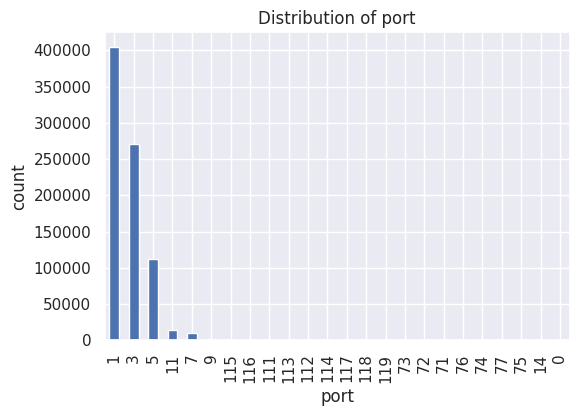

In [30]:
import matplotlib.pyplot as plt 
df_mhd_ch4_v3['port'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Distribution of port")
plt.xlabel('port')
plt.ylabel('count')
plt.show()

Port 1, 3, 5 are the most used ones

# instrument states

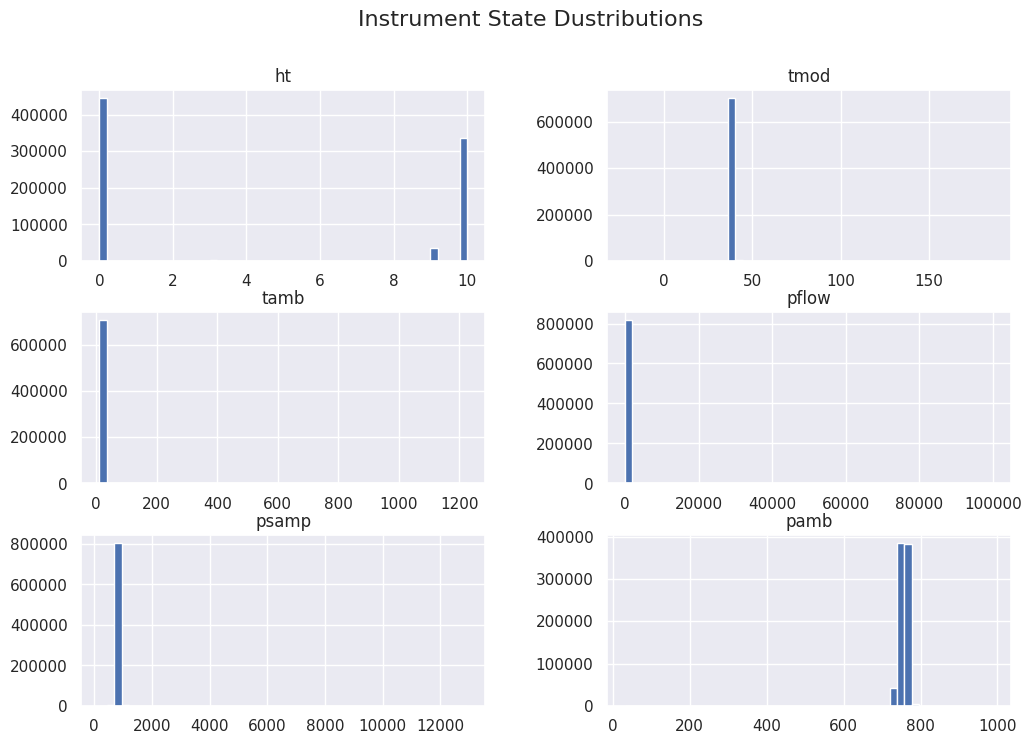

In [31]:
import matplotlib.pyplot as plt
#'temp', 'ploop' nan too many removed
cols = ['ht', 'tmod',  'tamb',  'pflow' , 'psamp', 'pamb']

df_mhd_ch4_v3[cols].hist(figsize=(12,8), bins=50)
plt.suptitle("Instrument State Dustributions", fontsize=16)
plt.show()

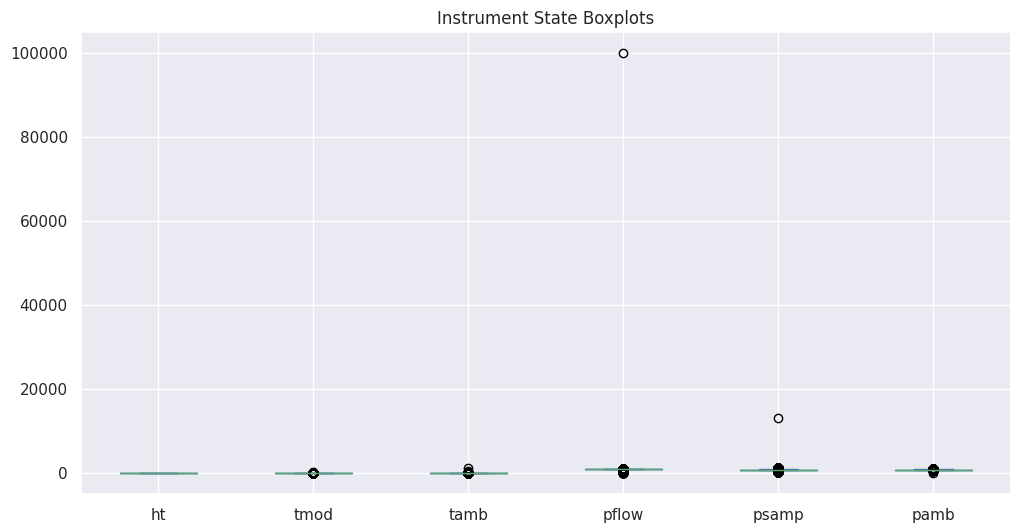

In [32]:
df_mhd_ch4_v3[cols].plot(kind='box', figsize=(12,6))
plt.title("Instrument State Boxplots")
plt.show()

**Explore instrument states by labels**



#not many useful insights -> convert it into markdown**
import seaborn as sns

for c in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='label', y=c, data=df_mhd_ch4_v3)
    plt.title(f"{c} by label")
    plt.show()

pflow has a data point at nearly 100000, psamp has one at 10000?
try to move the 100000 one

In [33]:
df_mhd_ch4_v3[df_mhd_ch4_v3['pflow']>=8000]

,date,time,type,sample,standard,port,ht,tmod,tamb,pflow,psamp,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,label
128952,990406,32600,std,J-030,J-030,1,0,40.0,20.27,99999.0,NaN,NaN,101.6,7.62,143978.0,1179415.0,1.08,89.2,136.2,20326.0,20306.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.736,NaN,1839.437,1,1,1


In [34]:
df_mhd_ch4_raw[df_mhd_ch4_raw['pflow']>=8000]

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
128952,990406,32600,std,J-030,J-030,1,0,40.0,20.27,NaN,99999.0,NaN,NaN,NaN,101.6,7.62,143978.0,1179415.0,1.08,89.2,136.2,20326.0,20306.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.736,NaN,1839.437,F,F,NaN,NaN


In [35]:
df_mhd_ch4_raw[df_mhd_ch4_raw['psamp']>=10000]

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
323309,61209,50400,std,J-097,J-097,1,0,40.0,22.64,NaN,810.3,12922.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.355,NaN,1861.378,F,F,NaN,NaN


flag_ht and flag_a were all bad
-> back check -> F flag

the psamp 12922-> flag h and flag a -> F

In [36]:
df_mhd_ch4_v3[cols].describe()

,ht,tmod,tamb,pflow,psamp,pamb
count,817955.000000,705671.000000,705671.000000,815553.000000,815626.000000,815551.000000
mean,4.491495,40.004842,20.890967,811.954561,757.492715,756.593960
std,4.928839,0.224623,2.302446,112.196125,30.281787,9.839729
min,0.000000,-22.000000,10.570000,0.000000,182.710000,31.900000
25%,0.000000,40.000000,19.780000,801.100000,750.570000,750.700000
50%,0.000000,40.000000,20.650000,809.700000,757.590000,757.600000
75%,10.000000,40.000000,21.650000,818.900000,763.550000,763.400000
max,10.000000,186.000000,1225.000000,99999.000000,12922.000000,987.500000


**drop extreme values from pflow and psamp**

In [37]:
df_mhd_ch4_drop = df_mhd_ch4_v3[(df_mhd_ch4_v3['psamp']<=10000) & (df_mhd_ch4_v3['pflow']<=90000)]

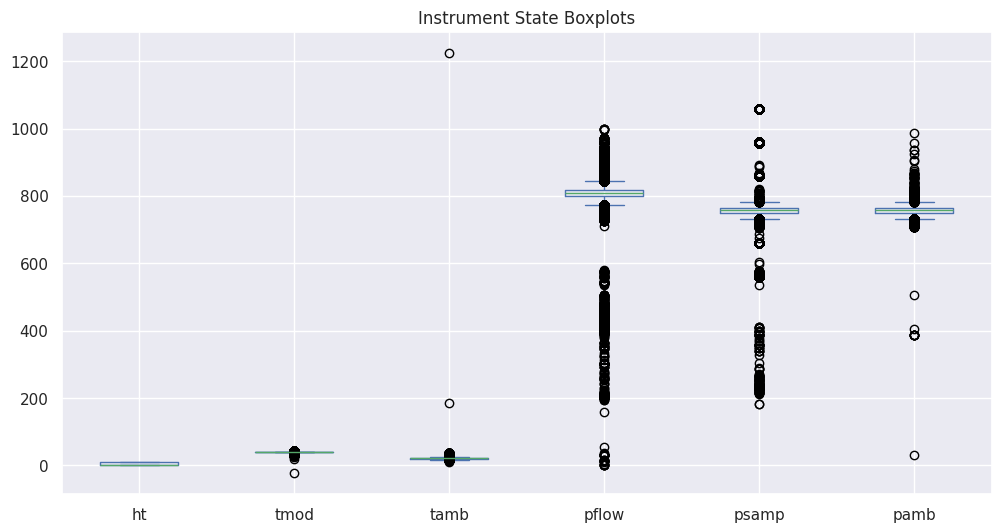

In [38]:
df_mhd_ch4_drop[cols].plot(kind='box', figsize=(12,6))
plt.title("Instrument State Boxplots")
plt.show()

# Explore peak features


In [39]:
cols = ['rt', 'w', "CH4_ht.1","CH4_area", "CH4_skew"]
df_mhd_ch4_v3[cols].describe()

,rt,w,CH4_ht.1,CH4_area,CH4_skew
count,816365.000000,816365.000000,816365.000000,8.163650e+05,816365.000000
mean,96.537053,7.828751,153152.635489,1.350951e+06,1.045182
std,14.293443,1.310069,31931.650989,2.814009e+05,0.165004
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,96.400000,7.690000,142966.000000,1.237542e+06,1.040000
50%,98.600000,7.870000,152208.000000,1.363757e+06,1.070000
75%,100.600000,8.370000,168307.000000,1.484501e+06,1.100000
max,166.600000,9.990000,999999.000000,9.999999e+06,9.940000


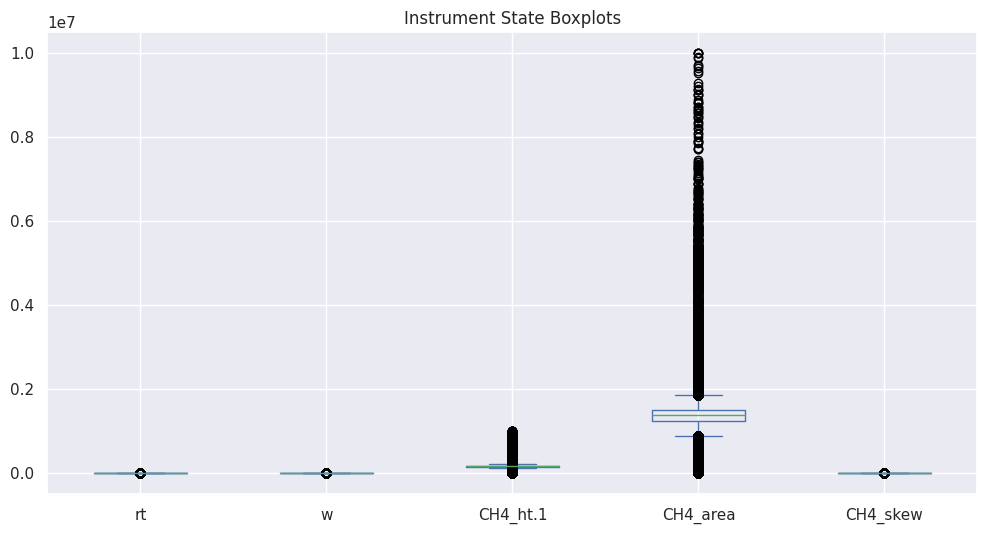

In [40]:
df_mhd_ch4_v3[cols].plot(kind='box', figsize=(12,6))
plt.title("Instrument State Boxplots")
plt.show()

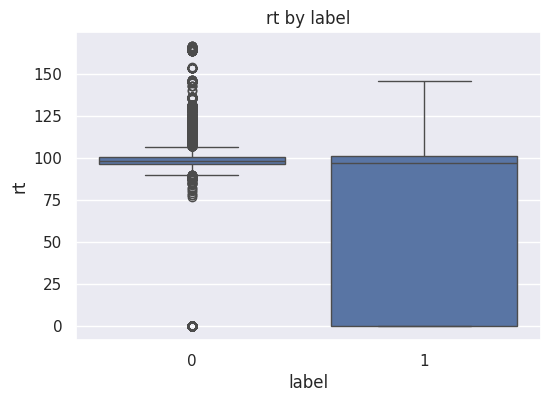

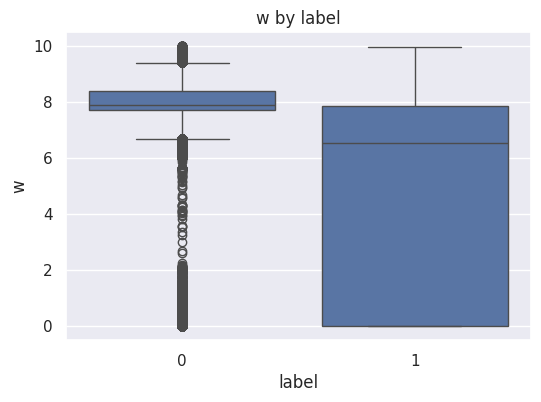

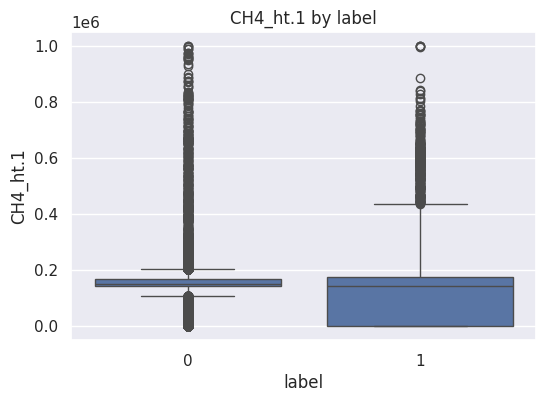

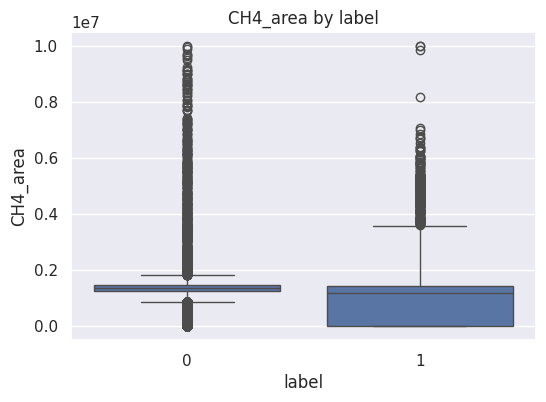

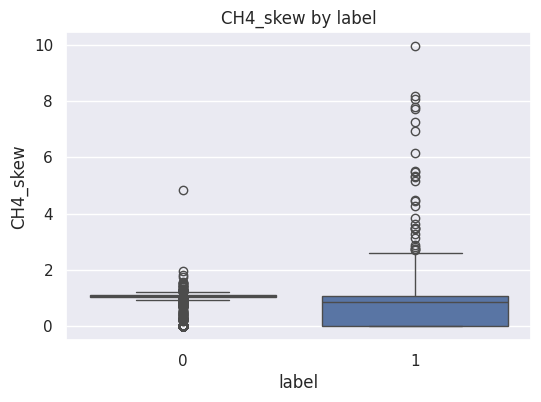

In [41]:
import seaborn as sns

for c in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='label', y=c, data=df_mhd_ch4_v3)
    plt.title(f"{c} by label")
    plt.show()

rt, w min = 0

explore it

In [42]:
df_mhd_ch4_raw[df_mhd_ch4_raw['rt']==0].head(20)
# head(1000) can see tank

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
10,940216,202300,air,10m,G-024,3,10,40.00,33.17,NaN,846.1,759.83,NaN,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
11,940216,204300,air,10m,G-024,3,10,40.00,33.05,NaN,846.3,759.91,NaN,759.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN


In [43]:
(df_mhd_ch4_raw['rt']==0).sum()

np.int64(16699)

rt == 0 -> most F flag

but if it's 'cal' type -> Nan

tank is also ->nan

In [44]:
df_mhd_ch4_raw[df_mhd_ch4_raw['w']==0].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
10,940216,202300,air,10m,G-024,3,10,40.00,33.17,NaN,846.1,759.83,NaN,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
11,940216,204300,air,10m,G-024,3,10,40.00,33.05,NaN,846.3,759.91,NaN,759.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN


In [45]:
(df_mhd_ch4_raw['w']==0).sum()

np.int64(16725)

w==0 -> 16725 data

rt = 0 -> 16699 data

==========

explore the data where rt = 0 but w is not 0

In [46]:
df_mhd_ch4_raw[(df_mhd_ch4_raw['w']==0) & (df_mhd_ch4_raw['rt']!=0)].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
2090,940322,93400,air,10m,G-024,3,10,40.01,25.09,NaN,836.9,754.15,NaN,NaN,90.2,0.0,0.0,0.0,0.76,83.6,90.8,28394.0,44771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.190,NaN,1692.489,NaN,NaN,NaN,NaN
135153,990706,112700,std,J-030,J-030,1,0,40.00,22.28,NaN,817.3,760.05,NaN,760.1,89.2,0.0,0.0,0.0,1.32,87.8,110.6,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.260,NaN,1839.437,F,F,NaN,NaN
218278,21015,162000,air,10m,J-062,3,10,40.00,20.66,NaN,812.0,752.05,NaN,752.1,105.4,0.0,0.0,0.0,1.44,104.0,126.8,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.654,NaN,1849.264,F,F,NaN,NaN
311839,60619,174000,std,J-091,J-091,1,0,40.00,20.30,NaN,809.1,756.68,NaN,756.8,98.6,0.0,0.0,0.0,1.25,93.0,123.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.441,NaN,1851.219,F,F,A,NaN
517178,140618,120400,std,J-166,J-166,3,0,40.00,24.62,NaN,808.6,769.71,NaN,769.6,87.4,0.0,0.0,0.0,0.51,81.6,108.2,17233.0,10466.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.236,NaN,1883.393,F,F,NaN,NaN
601021,170930,112300,std,J-206,J-206,11,0,40.00,18.03,NaN,802.8,755.22,NaN,755.0,99.0,0.0,154611.0,1734697.0,1.00,81.0,146.4,32451.0,33496.0,1.00123,0.99736,1.00123,1.0013,0.9974,0.9954,1.00123,0.99736,1.00123,1948.40,1940.88,1948.40,1.675,NaN,1946.007,NaN,NaN,NaN,NaN
601146,171002,54300,labair,labair,J-206,9,0,40.00,17.51,NaN,207.9,254.09,NaN,755.3,97.8,0.0,153417.0,1728162.0,1.16,80.4,145.8,32992.0,34350.0,2.96066,2.90195,2.96066,0.9965,0.9768,0.9758,2.96066,2.90195,2.96066,5761.47,5647.22,5761.47,1.682,NaN,1946.007,NaN,NaN,NaN,NaN
604180,171113,234500,air,10m,J-206,1,10,40.00,20.03,NaN,780.3,762.69,NaN,762.8,98.8,0.0,154006.0,1723995.0,1.01,80.8,146.0,35419.0,36567.0,0.98362,0.98675,0.98362,0.9837,0.9868,1.0032,0.98362,0.98675,0.98362,1914.13,1920.22,1914.13,1.840,1.810,1946.007,NaN,NaN,NaN,NaN
604183,171114,10500,air,10m,J-206,1,10,40.00,20.17,NaN,780.9,762.89,NaN,762.8,98.8,0.0,154217.0,1725930.0,1.03,81.0,145.8,35361.0,36557.0,0.98396,0.98635,0.98396,0.9840,0.9864,1.0025,0.98396,0.98635,0.98396,1914.79,1919.44,1914.79,1.785,1.756,1946.007,NaN,NaN,NaN,NaN
604198,171114,60500,std,J-206,J-206,11,0,40.00,20.13,NaN,809.3,762.11,NaN,762.0,98.8,0.0,156727.0,1755617.0,1.03,80.8,146.0,35955.0,37166.0,1.00089,1.00456,1.00089,1.0009,1.0045,1.0025,1.00089,1.00456,1.00089,1947.73,1954.87,1947.73,1.797,NaN,1946.007,NaN,NaN,NaN,NaN


In [47]:
((df_mhd_ch4_raw['w']==0) & (df_mhd_ch4_raw['rt']!=0)).sum()

np.int64(26)

In [48]:
df_mhd_ch4_raw[(df_mhd_ch4_raw['w']==0) & (df_mhd_ch4_raw['rt']!=0)]


,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
2090,940322,93400,air,10m,G-024,3,10,40.01,25.09,NaN,836.9,754.15,NaN,NaN,90.2,0.0,0.0,0.0,0.76,83.6,90.8,28394.0,44771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.190,NaN,1692.489,NaN,NaN,NaN,NaN
135153,990706,112700,std,J-030,J-030,1,0,40.00,22.28,NaN,817.3,760.05,NaN,760.1,89.2,0.0,0.0,0.0,1.32,87.8,110.6,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.260,NaN,1839.437,F,F,NaN,NaN
218278,21015,162000,air,10m,J-062,3,10,40.00,20.66,NaN,812.0,752.05,NaN,752.1,105.4,0.0,0.0,0.0,1.44,104.0,126.8,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.654,NaN,1849.264,F,F,NaN,NaN
311839,60619,174000,std,J-091,J-091,1,0,40.00,20.30,NaN,809.1,756.68,NaN,756.8,98.6,0.0,0.0,0.0,1.25,93.0,123.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.441,NaN,1851.219,F,F,A,NaN
517178,140618,120400,std,J-166,J-166,3,0,40.00,24.62,NaN,808.6,769.71,NaN,769.6,87.4,0.0,0.0,0.0,0.51,81.6,108.2,17233.0,10466.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.236,NaN,1883.393,F,F,NaN,NaN
601021,170930,112300,std,J-206,J-206,11,0,40.00,18.03,NaN,802.8,755.22,NaN,755.0,99.0,0.0,154611.0,1734697.0,1.00,81.0,146.4,32451.0,33496.0,1.00123,0.99736,1.00123,1.0013,0.9974,0.9954,1.00123,0.99736,1.00123,1948.40,1940.88,1948.40,1.675,NaN,1946.007,NaN,NaN,NaN,NaN
601146,171002,54300,labair,labair,J-206,9,0,40.00,17.51,NaN,207.9,254.09,NaN,755.3,97.8,0.0,153417.0,1728162.0,1.16,80.4,145.8,32992.0,34350.0,2.96066,2.90195,2.96066,0.9965,0.9768,0.9758,2.96066,2.90195,2.96066,5761.47,5647.22,5761.47,1.682,NaN,1946.007,NaN,NaN,NaN,NaN
604180,171113,234500,air,10m,J-206,1,10,40.00,20.03,NaN,780.3,762.69,NaN,762.8,98.8,0.0,154006.0,1723995.0,1.01,80.8,146.0,35419.0,36567.0,0.98362,0.98675,0.98362,0.9837,0.9868,1.0032,0.98362,0.98675,0.98362,1914.13,1920.22,1914.13,1.840,1.810,1946.007,NaN,NaN,NaN,NaN
604183,171114,10500,air,10m,J-206,1,10,40.00,20.17,NaN,780.9,762.89,NaN,762.8,98.8,0.0,154217.0,1725930.0,1.03,81.0,145.8,35361.0,36557.0,0.98396,0.98635,0.98396,0.9840,0.9864,1.0025,0.98396,0.98635,0.98396,1914.79,1919.44,1914.79,1.785,1.756,1946.007,NaN,NaN,NaN,NaN
604198,171114,60500,std,J-206,J-206,11,0,40.00,20.13,NaN,809.3,762.11,NaN,762.0,98.8,0.0,156727.0,1755617.0,1.03,80.8,146.0,35955.0,37166.0,1.00089,1.00456,1.00089,1.0009,1.0045,1.0025,1.00089,1.00456,1.00089,1947.73,1954.87,1947.73,1.797,NaN,1946.007,NaN,NaN,NaN,NaN


In [49]:
df_mhd_ch4_raw[df_mhd_ch4_raw['pflow']==0].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
776630,241008,55600,tank,H-055,J-273,115,0,40.0,18.44,NaN,0.0,739.63,NaN,739.3,98.8,7.82,153228.0,1328790.0,1.04,85.4,136.8,22380.0,22542.0,0.93,0.93006,0.93006,0.9305,0.9306,1.0007,0.93,0.93006,0.93006,1857.28,1857.4,1857.4,3.172,NaN,1997.08,NaN,NaN,A,NaN


**Summary of w and rt**

one of them is zero means a potentially error

make them as labels?

**ch4_ht.1 and area**
skew can be an potential important QC feature(much obvious difference between 0 and 1)

CH4_ht.1 : label 1, 2 obvious extreme values(0ver 0.95*1e6)

CH4_area : label 1, 2 obvious extreme values(0ver 0.9*1e7)

In [50]:
df_mhd_ch4_raw[(df_mhd_ch4_raw['CH4_ht.1']>= 0.95*1e6)&(df_mhd_ch4_v3['label']==1)].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
307646,60421,143300,air,10m,J-091,3,10,40.01,21.84,NaN,816.0,762.79,NaN,762.7,110.4,1.92,996082.0,8171550.0,1.75,107.2,116.0,28728.0,22466.0,7.47151,7.0957,NaN,27.4749,7.0966,0.2645,7.47151,7.0957,NaN,50855.8,13135.7,NaN,3.600,NaN,1851.219,F,F,NaN,NaN
377766,90121,112300,tank,499310,J-116,11,0,40.00,19.52,NaN,773.8,737.68,NaN,737.2,90.4,4.72,999999.0,9999999.0,5.48,79.4,471.8,10400.0,38773.0,54.43320,907.0630,NaN,454.6660,908.0400,4.1867,54.43320,907.0630,NaN,858205.0,3601524.0,NaN,4.297,NaN,1888.518,F,F,NaN,NaN
661957,200227,101200,tank,F38PMQ,J-231,11,0,40.00,20.24,NaN,810.0,753.18,NaN,753.3,99.2,3.11,999999.0,9999999.0,9.94,88.2,271.4,35149.0,52675.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1931.478,F,F,NaN,NaN
706587,211201,105500,labair,labair,J-246,9,0,40.00,22.73,NaN,415.3,727.16,NaN,755.4,97.2,2.33,999999.0,5039744.0,2.05,81.2,163.6,24715.0,30803.0,92.23980,50.8062,NaN,666.4740,41.4710,0.3033,92.23980,50.8062,NaN,1328418.0,481301.0,NaN,4.826,NaN,1919.014,F,F,NaN,NaN


In [51]:
df_mhd_ch4_raw[(df_mhd_ch4_raw['CH4_area']>= 0.9*1e7)&(df_mhd_ch4_v3['label']==1)].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
218275,21015,152000,std,J-062,J-062,1,0,40.01,20.96,NaN,802.9,751.93,NaN,751.9,111.4,1.34,354322.0,9881074.0,1.28,100.0,119.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.687,NaN,1849.264,F,F,NaN,NaN
377766,90121,112300,tank,499310,J-116,11,0,40.00,19.52,NaN,773.8,737.68,NaN,737.2,90.4,4.72,999999.0,9999999.0,5.48,79.4,471.8,10400.0,38773.0,54.4332,907.063,NaN,454.666,908.04,4.1867,54.4332,907.063,NaN,858205.0,3601524.0,NaN,4.297,NaN,1888.518,F,F,NaN,NaN
661957,200227,101200,tank,F38PMQ,J-231,11,0,40.00,20.24,NaN,810.0,753.18,NaN,753.3,99.2,3.11,999999.0,9999999.0,9.94,88.2,271.4,35149.0,52675.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1931.478,F,F,NaN,NaN


**Findings**

peak fitting error so use the maximum as error code?

# Calibration/Normalization EDA

In [52]:
cols = ['CH4_Rl_ht', 'CH4_Rl_a', 'CH4_Rl', 'CH4_norm_ht', 'CH4_norm_a', 'CH4_norm_w', 'CH4_R_ht', 'CH4_R_a', 'CH4_R' ]
df_mhd_ch4_v3[cols].describe()

,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R
count,766708.000000,768463.000000,759281.000000,766708.000000,766708.000000,766708.000000,766708.000000,768463.000000,759281.000000
mean,1.007850,1.009200,1.006545,1.011424,1.010579,0.997909,1.007850,1.009200,1.006545
std,0.171006,1.042309,0.099420,0.945243,1.044619,0.050592,0.171006,1.042309,0.099420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.998330,0.998610,0.998430,0.998400,0.998600,0.998900,0.998330,0.998610,0.998430
50%,1.000620,1.000520,1.000600,1.000700,1.000600,1.000000,1.000620,1.000520,1.000600
75%,1.006980,1.006480,1.006740,1.007300,1.007300,1.001100,1.006980,1.006480,1.006740
max,92.239800,907.063000,9.955460,666.474000,908.040000,4.186700,92.239800,907.063000,9.955460


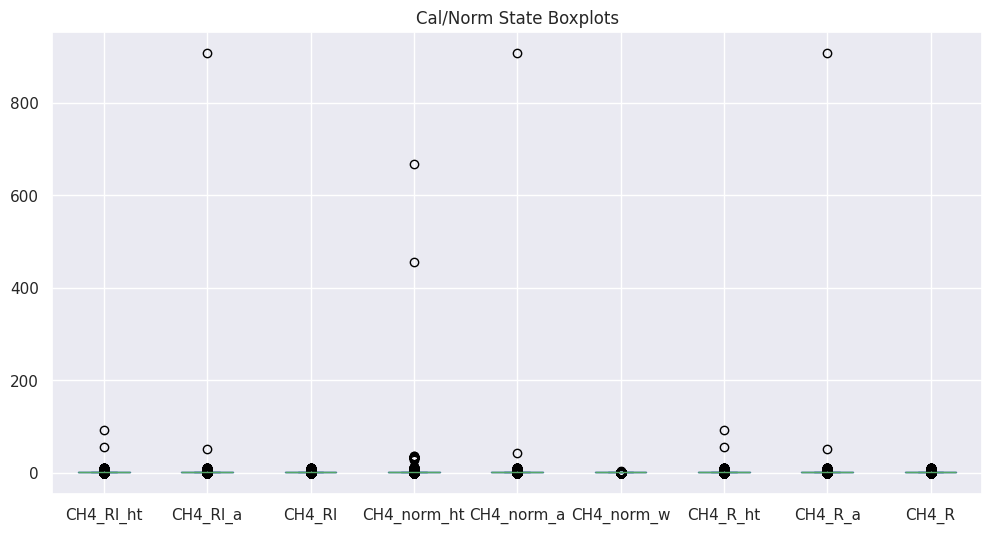

In [53]:
df_mhd_ch4_v3[cols].plot(kind='box', figsize=(12,6))
plt.title("Cal/Norm State Boxplots")
plt.show()

CH4_Rl_ht: 2 extreme values , >10?
CH4_Rl_a: 2 extreme values, > 10 ?
CH4_norm_ht: 2 extreme values, > 400
Ch4_norm_a: 2 extreme values, > 10?
CH4_R_ht: 2 extreme values > 10,
CH4_R_a: 2 extreme, >10

df_mhd_ch4_raw[df_mhd_ch4_raw['CH4_Rl_ht'] > 10].head(20)

In [54]:
for c in cols:
    if c =='CH4_norm_ht':
        print(f'{c}:extreme values:\n', df_mhd_ch4_raw[df_mhd_ch4_raw[c] > 400].head(20),'\n')
    else:
        print(f'{c}:extreme values:\n', df_mhd_ch4_raw[df_mhd_ch4_raw[c] > 10].head(20), '\n')
    print('==================================================')


CH4_Rl_ht:extreme values:
           date    time    type  sample standard  port  ht  tmod   tamb  temp  \
377766   90121  112300    tank  499310    J-116    11   0  40.0  19.52   NaN   
706587  211201  105500  labair  labair    J-246     9   0  40.0  22.73   NaN   

        pflow   psamp  ploop   pamb    rt     w  CH4_ht.1   CH4_area  \
377766  773.8  737.68    NaN  737.2  90.4  4.72  999999.0  9999999.0   
706587  415.3  727.16    NaN  755.4  97.2  2.33  999999.0  5039744.0   

        CH4_skew  CH4_start_time  CH4_end_time  CH4_start_level  \
377766      5.48            79.4         471.8          10400.0   
706587      2.05            81.2         163.6          24715.0   

        CH4_end_level  CH4_Rl_ht  CH4_Rl_a  CH4_Rl  CH4_norm_ht  CH4_norm_a  \
377766        38773.0    54.4332  907.0630     NaN      454.666     908.040   
706587        30803.0    92.2398   50.8062     NaN      666.474      41.471   

        CH4_norm_w  CH4_R_ht   CH4_R_a  CH4_R   CH4_C_ht    CH4_C_a  CH4_C 

Are all :
    377766 
    706587

same results with  CH4_ht.1 extreme CH4_area extreme.
CH4_RI no extreme -> because is NAN in both 377766, and 706587
 => same as CH4_R (NAN)

notice: rt and w are not 0.0
------------
Cal/Norm worng -> peak fitting error -> ht/area error -> flag F ?
-----------
maybe the error are two types?
peak fitting error 
and 
calibration error
( has peak but)


**convert time to plot time-series data**

In [55]:
df_mhd_ch4_time = df_mhd_ch4_v3.copy()
df_mhd_ch4_time['date'] = df_mhd_ch4_time['date'].astype(str).str.zfill(6)
df_mhd_ch4_time['time'] = df_mhd_ch4_time['time'].astype(str).str.zfill(6)

df_mhd_ch4_time['datetime_str'] = df_mhd_ch4_time['date'] + df_mhd_ch4_time['time']

df_mhd_ch4_time['datetime'] = pd.to_datetime(df_mhd_ch4_time['datetime_str'], format='%y%m%d%H%M%S')

df_mhd_ch4_time.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,pflow,psamp,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,label,datetime_str,datetime
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,841.9,761.10,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216142900,1994-02-16 14:29:00
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,840.4,761.07,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216144900,1994-02-16 14:49:00
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,839.4,760.99,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216150900,1994-02-16 15:09:00
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,839.6,760.96,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,0,0,0,940216152900,1994-02-16 15:29:00
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,845.4,760.72,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216180000,1994-02-16 18:00:00
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,846.2,760.60,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216182000,1994-02-16 18:20:00
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,846.3,760.57,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216184000,1994-02-16 18:40:00
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,846.5,760.45,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216190000,1994-02-16 19:00:00
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,846.6,760.34,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216192000,1994-02-16 19:20:00
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,844.8,760.35,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216194000,1994-02-16 19:40:00


/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


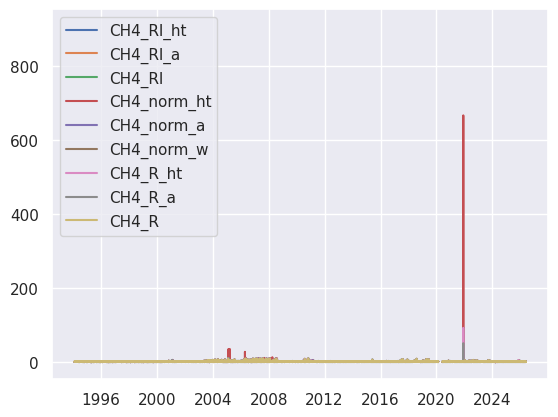

In [56]:
for c in cols:
    plt.plot(df_mhd_ch4_time['datetime'], df_mhd_ch4_time[c], label=c)

plt.legend()
plt.show()

In [57]:
df_mhd_ch4_time[(df_mhd_ch4_time['datetime']>'2020-01-01')].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,pflow,psamp,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,label,datetime_str,datetime
657883,200101,001800,std,J-223,J-223,3,0,40.0,20.33,816.3,768.26,768.1,99.8,6.87,136408.0,1099702.0,0.93,86.4,137.4,26348.0,26657.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.277,NaN,1922.093,0,0,0,200101001800,2020-01-01 00:18:00
657884,200101,005800,std,J-223,J-223,3,0,40.0,20.72,815.9,767.80,767.8,99.8,6.87,136335.0,1099447.0,0.93,86.4,137.6,26558.0,26794.0,1.00129,1.00162,1.00129,1.0013,1.0016,0.9999,1.00129,1.00162,1.00129,1924.58,1925.21,1924.58,5.334,NaN,1922.093,0,0,0,200101005800,2020-01-01 00:58:00
657885,200101,011800,air,10m,J-223,1,10,40.0,20.69,814.5,767.48,767.5,99.8,6.86,142144.0,1145919.0,0.93,86.4,137.6,26470.0,26728.0,1.04434,1.04419,1.04434,1.0442,1.0441,1.0001,1.04434,1.04419,1.04434,2007.32,2007.03,2007.32,5.349,5.586,1922.093,0,0,0,200101011800,2020-01-01 01:18:00
657886,200101,013800,std,J-223,J-223,3,0,40.0,20.77,815.3,767.33,767.2,99.8,6.86,135910.0,1095634.0,0.93,86.4,137.4,26412.0,26687.0,0.99874,1.00132,0.99874,0.9988,1.0013,0.9991,0.99874,1.00132,0.99874,1919.67,1924.63,1919.67,5.386,NaN,1922.093,0,0,0,200101013800,2020-01-01 01:38:00
657887,200101,015800,air,10m,J-223,1,10,40.0,20.61,814.1,767.04,766.9,100.0,6.89,141360.0,1144588.0,0.90,86.4,137.8,26594.0,26839.0,1.04050,1.04797,1.04050,1.0404,1.0479,1.0040,1.04050,1.04797,1.04050,1999.93,2014.30,1999.93,5.386,5.604,1922.093,0,0,0,200101015800,2020-01-01 01:58:00
657888,200101,021800,std,J-223,J-223,3,0,40.0,20.45,814.7,766.84,766.8,100.0,6.87,135823.0,1088894.0,0.91,86.8,137.6,27013.0,26824.0,0.99686,0.98853,0.99686,0.9964,0.9881,0.9985,0.99686,0.98853,0.99686,1916.07,1900.04,1916.07,5.370,NaN,1922.093,0,0,0,200101021800,2020-01-01 02:18:00
657889,200101,023800,air,10m,J-223,1,10,40.0,20.66,811.8,766.74,766.7,100.0,6.89,144405.0,1169116.0,0.90,86.4,138.0,26456.0,26789.0,1.05998,1.06440,1.05998,1.0597,1.0641,1.0005,1.05998,1.06440,1.05998,2037.39,2045.88,2037.39,5.370,5.692,1922.093,0,0,0,200101023800,2020-01-01 02:38:00
657890,200101,025800,std,J-223,J-223,3,0,40.0,20.72,814.9,767.04,766.8,100.0,6.90,136714.0,1108434.0,0.90,86.6,137.8,26524.0,26787.0,1.00475,1.01478,1.00475,1.0048,1.0149,1.0052,1.00475,1.01478,1.00475,1931.22,1950.50,1931.22,5.397,NaN,1922.093,0,0,0,200101025800,2020-01-01 02:58:00
657891,200101,031800,air,10m,J-223,1,10,40.0,20.64,814.1,766.93,766.9,100.0,6.88,142815.0,1154167.0,0.91,86.6,138.0,26493.0,26812.0,1.04645,1.04757,1.04645,1.0462,1.0474,0.9996,1.04645,1.04757,1.04645,2011.37,2013.53,2011.37,5.361,5.610,1922.093,0,0,0,200101031800,2020-01-01 03:18:00
657892,200101,033800,std,J-223,J-223,3,0,40.0,20.73,815.1,767.13,766.8,100.0,6.86,136294.0,1095534.0,0.92,86.6,137.6,26823.0,26804.0,0.99848,0.99140,0.99848,0.9986,0.9915,0.9952,0.99848,0.99140,0.99848,1919.17,1905.56,1919.17,5.361,NaN,1922.093,0,0,0,200101033800,2020-01-01 03:38:00


values are all near 1.

because before 2020 are all Nan values?

In [58]:
df_mhd_ch4_timedrop = df_mhd_ch4_time

# Event level EDA

In [59]:
df_mhd_ch4_v4 = df_mhd_ch4_time.copy()

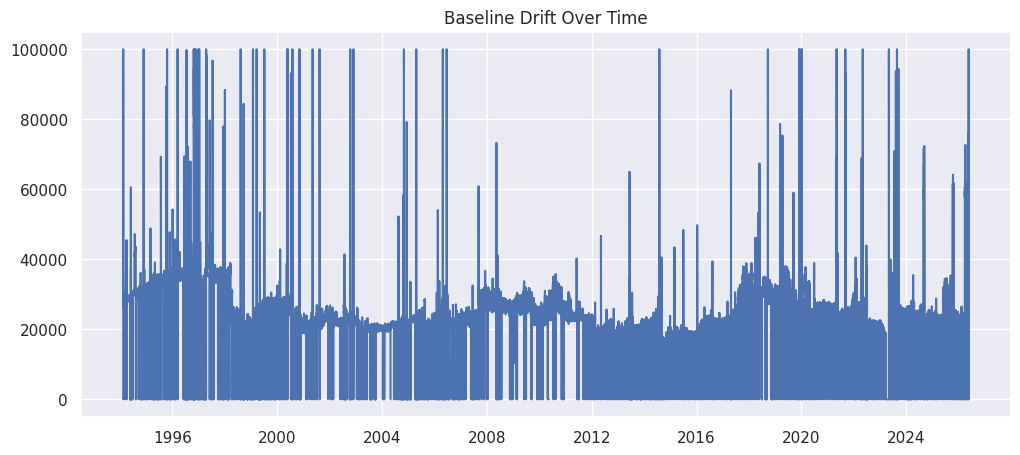

In [60]:
df_mhd_ch4_v4['baseline_drift'] = df_mhd_ch4_v4['CH4_end_level'] = df_mhd_ch4_v4['CH4_start_level']
plt.figure(figsize=(12,5))
plt.plot(df_mhd_ch4_v4['datetime'], df_mhd_ch4_v4['baseline_drift'])
plt.title('Baseline Drift Over Time')
plt.show()

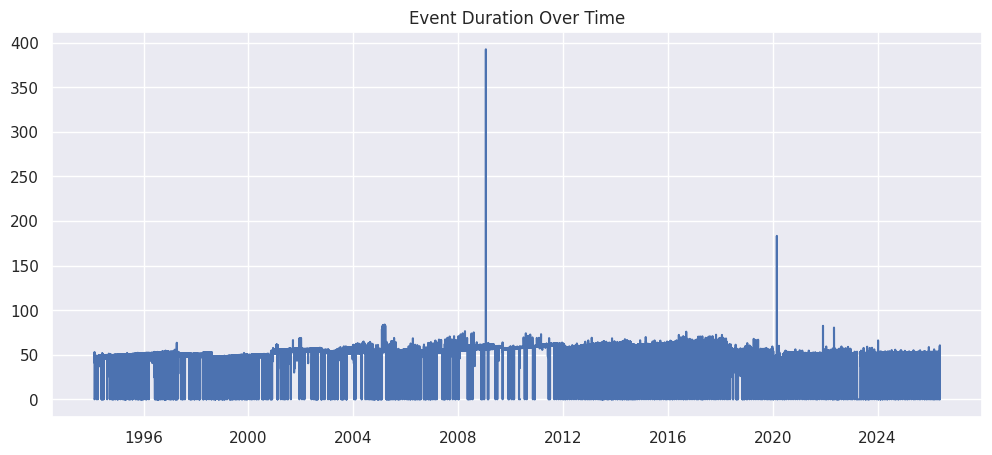

In [61]:
df_mhd_ch4_v4['duration'] = (df_mhd_ch4_v4['CH4_end_time']- df_mhd_ch4_v4['CH4_start_time'])

plt.figure(figsize=(12,5))
plt.plot(df_mhd_ch4_v4['datetime'], df_mhd_ch4_v4['duration'])
plt.title("Event Duration Over Time")
plt.show()

In [62]:
# examine duration spike
df_mhd_ch4_v4[df_mhd_ch4_v4['duration'] > 100].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,pflow,psamp,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,label,datetime_str,datetime,baseline_drift,duration
377766,090121,112300,tank,499310,J-116,11,0,40.0,19.52,773.8,737.68,737.2,90.4,4.72,999999.0,9999999.0,5.48,79.4,471.8,10400.0,10400.0,54.4332,907.063,NaN,454.666,908.04,4.1867,54.4332,907.063,NaN,858205.0,3601524.0,NaN,4.297,NaN,1888.518,1,1,1,090121112300,2009-01-21 11:23:00,10400.0,392.4
377772,090121,132300,tank,509613,J-116,11,0,40.0,19.95,779.4,735.29,735.2,89.8,4.32,999999.0,9999999.0,4.83,78.2,470.6,24944.0,24944.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.234,NaN,1888.518,0,0,0,090121132300,2009-01-21 13:23:00,24944.0,392.4
661957,200227,101200,tank,F38PMQ,J-231,11,0,40.0,20.24,810.0,753.18,753.3,99.2,3.11,999999.0,9999999.0,9.94,88.2,271.4,35149.0,35149.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1931.478,1,1,1,200227101200,2020-02-27 10:12:00,35149.0,183.2


CH4_ht.1 and CH4_area all 999999.0 
all tank type

duration spike -> error?

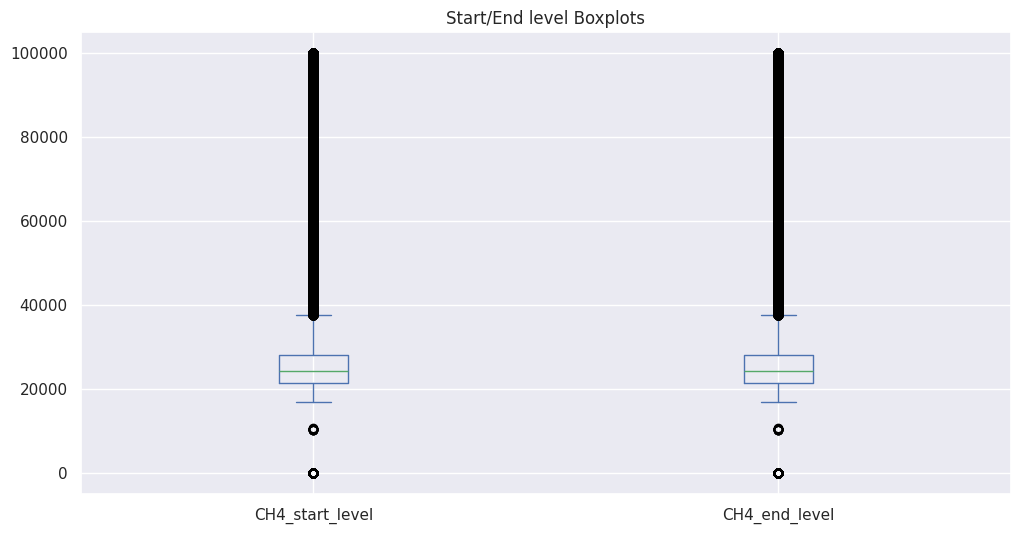

In [63]:
df_mhd_ch4_v4[['CH4_start_level','CH4_end_level']].plot(kind='box', figsize=(12,6))
plt.title("Start/End level Boxplots")
plt.show()

# explore sample and port (boxplot)

Text(0.5, 1.0, 'sample vs. ch4_c')

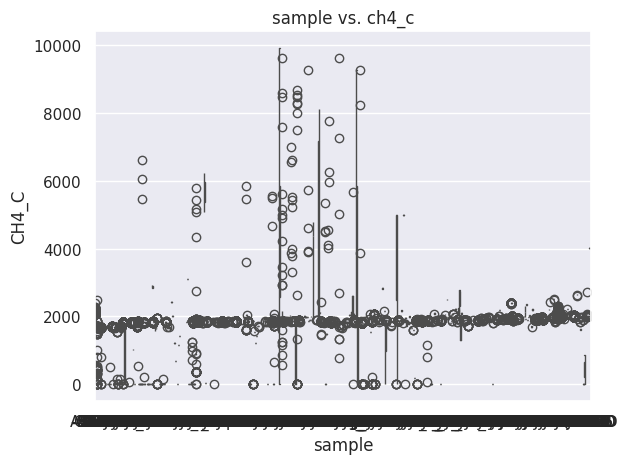

In [64]:
sns.boxplot(x='sample', y='CH4_C', data=df_mhd_ch4_v3)
plt.title('sample vs. ch4_c')

Text(0.5, 1.0, 'Port vs. rt')

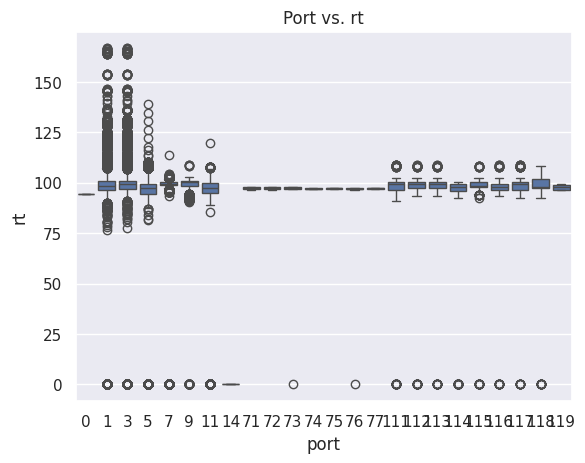

In [65]:
sns.boxplot(x='port', y='rt', data=df_mhd_ch4_v3)
plt.title('Port vs. rt')

Text(0.5, 1.0, 'Port vs. W')

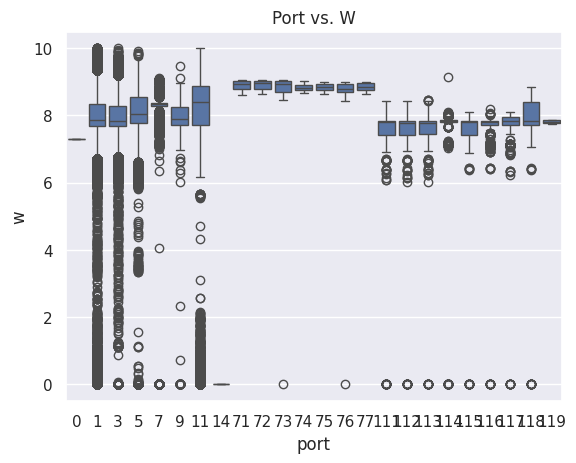

In [66]:
sns.boxplot(x='port', y='w', data=df_mhd_ch4_v3)
plt.title('Port vs. W')


===================================================

label 1 data distribution in ht and a are almost the same
that potentially means ht and area are highly related.

# Feature Engineering

Already know
CH4_ht.1 == 999999999
CH4_area == 999999999
rt == 0
w == 0
-------- error

seen flag NAN as correct data

In [105]:
df_mhd_ml_v1 = df_mhd_ch4_raw.copy()

In [106]:
df_mhd_ml_v1 ["CH4_flag"] = df_mhd_ml_v1 ["CH4_flag"].fillna(" ")
df_mhd_ml_v1 ["CH4_flag_ht"] = df_mhd_ml_v1 ["CH4_flag_ht"].fillna(" ")
df_mhd_ml_v1 ["CH4_flag_a"] = df_mhd_ml_v1 ["CH4_flag_a"].fillna(" ")

In [107]:
df_mhd_ml_v1 ["CH4_flag_raw"] = df_mhd_ml_v1 ["CH4_flag"]
df_mhd_ml_v1 ["CH4_flag_ht_raw"] = df_mhd_ml_v1 ["CH4_flag_ht"]
df_mhd_ml_v1 ["CH4_flag_a_raw"] = df_mhd_ml_v1 ["CH4_flag_a"]

In [108]:
df_mhd_ml_v1.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,NaN,,,
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F


In [109]:
mapping={" ":0, 
          "x":1, 
          "*":1,
          "F":1, 
          "B":1, 
        }

df_mhd_ml_v1 ["CH4_flag_ht_bin"] = df_mhd_ml_v1 ["CH4_flag_ht_raw"].map(mapping)
df_mhd_ml_v1 ["CH4_flag_a_bin"] = df_mhd_ml_v1 ["CH4_flag_a_raw"].map(mapping)


In [ ]:
# prevent NAN values, NAN -> 0 (good)
df_mhd_ml_v1 ["CH4_flag_ht_bin"] = df_mhd_ml_v1 ["CH4_flag_ht_bin"].fillna(0)
df_mhd_ml_v1 ["CH4_flag_a_bin"] = df_mhd_ml_v1 ["CH4_flag_a_bin"].fillna(0)

In [111]:
df_mhd_ml_v1['label1'] = (
    (df_mhd_ml_v1['CH4_flag_ht_bin'] == 1) |
    (df_mhd_ml_v1['CH4_flag_a_bin'] == 1)
).astype(int)

In [112]:
df_mhd_ml_v1.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,NaN,,,,0,0,0
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1


datetime create

In [113]:
df_mhd_ml_v1['date'] = df_mhd_ml_v1['date'].astype(str).str.zfill(6)
df_mhd_ml_v1['time'] = df_mhd_ml_v1['time'].astype(str).str.zfill(6)

df_mhd_ml_v1['datetime_str'] = df_mhd_ml_v1['date'] + df_mhd_ml_v1['time']

df_mhd_ml_v1['datetime'] = pd.to_datetime(df_mhd_ml_v1['datetime_str'], format='%y%m%d%H%M%S')

df_mhd_ml_v1.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216142900,1994-02-16 14:29:00
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216144900,1994-02-16 14:49:00
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216150900,1994-02-16 15:09:00
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,NaN,,,,0,0,0,940216152900,1994-02-16 15:29:00
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216180000,1994-02-16 18:00:00
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216182000,1994-02-16 18:20:00
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216184000,1994-02-16 18:40:00
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216190000,1994-02-16 19:00:00
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216192000,1994-02-16 19:20:00
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216194000,1994-02-16 19:40:00


In [114]:
df_mhd_ml_v1['is_ht_999'] = (df_mhd_ml_v1['CH4_ht.1'] == 9999999.0)
df_mhd_ml_v1['is_area_999'] = (df_mhd_ml_v1['CH4_area'] == 9999999.0) 

In [115]:
df_mhd_ml_v1[df_mhd_ml_v1['is_area_999'] == True]

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999
377766,090121,112300,tank,499310,J-116,11,0,40.0,19.52,NaN,773.8,737.68,NaN,737.2,90.4,4.72,999999.0,9999999.0,5.48,79.4,471.8,10400.0,38773.0,54.4332,907.063,NaN,454.666,908.04,4.1867,54.4332,907.063,NaN,858205.0,3601524.0,NaN,4.297,NaN,1888.518,F,F,,NaN,,F,F,1,1,1,090121112300,2009-01-21 11:23:00,False,True
377772,090121,132300,tank,509613,J-116,11,0,40.0,19.95,NaN,779.4,735.29,NaN,735.2,89.8,4.32,999999.0,9999999.0,4.83,78.2,470.6,24944.0,39475.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.234,NaN,1888.518,,,,NaN,,,,0,0,0,090121132300,2009-01-21 13:23:00,False,True
661957,200227,101200,tank,F38PMQ,J-231,11,0,40.0,20.24,NaN,810.0,753.18,NaN,753.3,99.2,3.11,999999.0,9999999.0,9.94,88.2,271.4,35149.0,52675.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1931.478,F,F,,NaN,,F,F,1,1,1,200227101200,2020-02-27 10:12:00,False,True


In [116]:
(df_mhd_ml_v1['is_area_999'] == True).sum()

np.int64(3)

In [117]:
df_mhd_ml_v1['is_rt_zero'] = (df_mhd_ml_v1['rt'] == 0)
df_mhd_ml_v1['is_w_zero'] = (df_mhd_ml_v1['w'] == 0)

In [118]:
print((df_mhd_ml_v1['is_rt_zero'] == True).sum())
print((df_mhd_ml_v1['is_w_zero'] == True).sum())

16699
16725


In [119]:
df_mhd_ml_v1['duration'] = (df_mhd_ml_v1['CH4_end_time'] - df_mhd_ml_v1['CH4_start_time'])
df_mhd_ml_v1['is_duration_spike'] = (df_mhd_ml_v1['duration']>100)


In [120]:
df_mhd_ml_v1['baseline_drift'] = df_mhd_ml_v1['CH4_end_level'] - df_mhd_ml_v1['CH4_start_level']


In [121]:
# df_mh_ml_v1['CalNorm_ratio'] not sure

In [122]:
df_mhd_ml_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817955 entries, 0 to 817954
Data columns (total 57 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   date               817955 non-null  object        
 1   time               817955 non-null  object        
 2   type               817954 non-null  object        
 3   sample             817955 non-null  object        
 4   standard           817955 non-null  object        
 5   port               817955 non-null  int64         
 6   ht                 817955 non-null  int64         
 7   tmod               705671 non-null  float64       
 8   tamb               705671 non-null  float64       
 9   temp               0 non-null       float64       
 10  pflow              815553 non-null  float64       
 11  psamp              815626 non-null  float64       
 12  ploop              0 non-null       float64       
 13  pamb               815551 non-null  float64 

**Create label2**

In [123]:
df_mhd_ml_v1['label2'] = (
    (df_mhd_ml_v1['label1'] == 1) |
    (df_mhd_ml_v1['is_ht_999'] == True)|
    (df_mhd_ml_v1['is_area_999'] == True)|
    (df_mhd_ml_v1['is_rt_zero'] == True)|
    (df_mhd_ml_v1['is_w_zero'] == True)|
    (df_mhd_ml_v1['is_duration_spike'] == True)
).astype(int)

In [124]:
df_mhd_ml_v1['ht_area_ratio'] = df_mhd_ml_v1['CH4_ht.1'] /df_mhd_ml_v1['CH4_area']

In [125]:
df_mhd_ml_v1.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,1,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,1,NaN
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,1,0.384554
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,NaN,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0,0.142279
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,1,NaN
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216182000,1994-02-16 18:20:00,False,False,True,True,0.0,False,0.0,1,NaN
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216184000,1994-02-16 18:40:00,False,False,True,True,0.0,False,0.0,1,NaN
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216190000,1994-02-16 19:00:00,False,False,True,True,0.0,False,0.0,1,NaN
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216192000,1994-02-16 19:20:00,False,False,True,True,0.0,False,0.0,1,NaN
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,NaN,,F,F,1,1,1,940216194000,1994-02-16 19:40:00,False,False,True,True,0.0,False,0.0,1,NaN


# Datasets

In [126]:
# Datasets A peak only
dataset_A_cols = [
    'rt', 'w', "CH4_ht.1","CH4_area", "CH4_skew",
    'is_ht_999', 'is_area_999',	'is_rt_zero', 'is_w_zero',
    'ht_area_ratio',
    'label1'
]

dataset_B_cols = [
    'rt', 'w', "CH4_ht.1","CH4_area", "CH4_skew",
    'is_ht_999', 'is_area_999',	'is_rt_zero', 'is_w_zero',
    'ht_area_ratio',
    'label1',
    'CH4_Rl_ht','CH4_Rl_a', 'CH4_Rl', 'CH4_norm_ht', 'CH4_norm_a', 'CH4_norm_w', 'CH4_R_ht', 'CH4_R_a', 'CH4_R', 'CH4_C_ht', 'CH4_C_a', 'CH4_C', 'CH4_std_stdev', 'CH4_std_rep', 'CH4_Cstd'
]

In [127]:
df_mhd_A = df_mhd_ml_v1[dataset_A_cols].copy()

In [128]:
df_mhd_A.head(20)

,rt,w,CH4_ht.1,CH4_area,CH4_skew,is_ht_999,is_area_999,is_rt_zero,is_w_zero,ht_area_ratio,label1
0,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
1,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
2,109.8,2.60,190908.0,496440.0,0.63,False,False,False,False,0.384554,1
3,94.8,6.85,151667.0,1065982.0,1.02,False,False,False,False,0.142279,0
4,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
5,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
6,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
7,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
8,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
9,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1


In [129]:
df_mhd_A_v2 = df_mhd_A.copy()

In [130]:
# convert ht_area_ration  NAN-> -999, 'cause randomforest cann't put NAN
df_mhd_A_v2['ht_area_ratio'] = df_mhd_A_v2['ht_area_ratio'].fillna(-999)

In [131]:
df_mhd_A_v2.head(20)

,rt,w,CH4_ht.1,CH4_area,CH4_skew,is_ht_999,is_area_999,is_rt_zero,is_w_zero,ht_area_ratio,label1
0,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
1,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
2,109.8,2.60,190908.0,496440.0,0.63,False,False,False,False,0.384554,1
3,94.8,6.85,151667.0,1065982.0,1.02,False,False,False,False,0.142279,0
4,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
5,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
6,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
7,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
8,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
9,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1


Dataset explain:
label1: CH4_flag_ht or CH4_flag_a is not space -> 1 (error); space, 0(correct)

# ML 

In [132]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np

X = df_mhd_A_v2.drop(columns=['label1'])
y = df_mhd_A_v2['label1']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# RF model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth = 12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99    155393
           1       0.73      0.69      0.71      8198

    accuracy                           0.97    163591
   macro avg       0.86      0.84      0.85    163591
weighted avg       0.97      0.97      0.97    163591



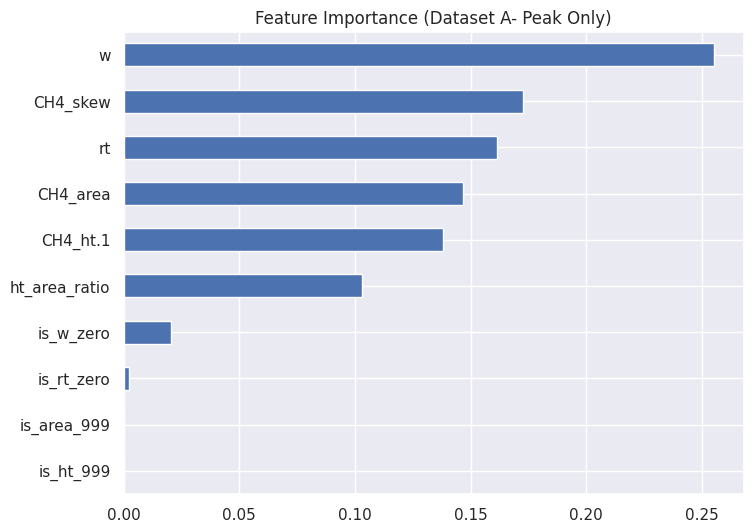

In [133]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Dataset A- Peak Only)")
plt.show()

99999 very less -> model not rely on them

In [134]:
# check the misclassified samples
misclassified = X_test[y_test != y_pred].copy()
misclassified['y_true'] = y_test[y_test != y_pred] # real answer
misclassified['y_pred'] = y_pred[y_test != y_pred]

print("Total of misclassified:", len(misclassified['y_true']))

Total of misclassified: 4608


In [135]:
(df_mhd_ml_v1.loc[misclassified.index]).head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio
78766,970326,154400,air,10m,J-012,3,10,40.01,22.08,NaN,843.3,756.94,NaN,757.0,96.4,7.62,158502.0,1328334.0,1.04,84.0,132.2,24929.0,24685.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1830.624,F,F,,NaN,,F,F,1,1,1,970326154400,1997-03-26 15:44:00,False,False,False,False,48.2,False,-244.0,1,0.119324
634832,190206,043300,air,10m,J-218,1,10,40.00,18.74,NaN,820.9,754.82,NaN,754.7,101.4,7.57,147518.0,1283225.0,0.98,87.4,141.2,29981.0,30328.0,1.00712,1.01669,NaN,1.0073,1.0169,1.0218,1.00712,1.01669,NaN,1948.25,1966.77,NaN,2.478,NaN,1934.484,*,*,,NaN,,*,*,1,1,1,190206043300,2019-02-06 04:33:00,False,False,False,False,53.8,False,347.0,1,0.114959
84960,970622,124200,std,J-016,J-016,1,0,40.00,20.41,NaN,859.2,752.16,NaN,752.2,95.8,7.84,188321.0,1623636.0,1.13,83.2,132.2,35698.0,35915.0,0.99936,0.99835,0.99936,0.9994,0.9984,0.9999,0.99936,0.99835,0.99936,1812.79,1810.95,1812.79,3.479,NaN,1813.938,,,,NaN,,,,0,0,0,970622124200,1997-06-22 12:42:00,False,False,False,False,49.0,False,217.0,0,0.115987
77002,970301,175800,air,10m,J-012,3,10,40.00,20.52,NaN,828.8,742.48,NaN,742.3,100.8,8.67,165412.0,1574586.0,1.03,87.2,138.0,30316.0,30809.0,0.99216,0.99294,0.99216,0.9923,0.9931,1.0003,0.99216,0.99294,0.99216,1816.27,1817.71,1816.27,2.660,2.639,1830.624,,,,NaN,,,,0,0,0,970301175800,1997-03-01 17:58:00,False,False,False,False,50.8,False,493.0,0,0.105051
161846,000726,090300,std,J-046,J-046,1,0,NaN,NaN,NaN,805.5,751.87,NaN,751.9,101.6,8.01,121049.0,1043166.0,1.01,89.0,136.6,21546.0,21711.0,1.00083,1.00149,1.00083,1.0008,1.0015,1.0011,1.00083,1.00149,1.00083,1860.65,1861.87,1860.65,10.311,NaN,1859.110,,,,NaN,,,,0,0,0,000726090300,2000-07-26 09:03:00,False,False,False,False,47.6,False,165.0,0,0.116040
130365,990426,165200,std,J-030,J-030,1,0,40.00,20.41,NaN,816.8,763.65,NaN,763.8,101.0,7.67,150196.0,1238060.0,1.03,88.4,135.8,22166.0,22126.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.377,NaN,1839.437,B,B,,NaN,,B,B,1,1,1,990426165200,1999-04-26 16:52:00,False,False,False,False,47.4,False,-40.0,1,0.121316
796930,250723,153400,air,9m,J-280,1,9,40.00,21.27,NaN,809.4,763.28,NaN,763.2,96.4,7.81,175347.0,1527382.0,1.07,83.0,135.6,29965.0,30306.0,1.02659,1.02614,NaN,1.0266,1.0262,0.9993,1.02659,1.02614,NaN,2057.70,2056.79,NaN,8.789,NaN,2004.399,F,F,A,NaN,A,F,F,1,1,1,250723153400,2025-07-23 15:34:00,False,False,False,False,52.6,False,341.0,1,0.114802
796879,250722,221400,air,9m,J-280,1,9,40.00,20.35,NaN,803.1,759.98,NaN,760.1,96.4,7.84,169246.0,1478045.0,1.10,83.0,135.4,29573.0,29798.0,0.99832,0.99989,NaN,0.9983,0.9999,1.0014,0.99832,0.99989,NaN,2001.02,2004.17,NaN,11.418,NaN,2004.399,F,F,A,NaN,A,F,F,1,1,1,250722221400,2025-07-22 22:14:00,False,False,False,False,52.4,False,225.0,1,0.114507
85188,970625,174700,air,10m,J-016,3,10,39.99,21.00,NaN,835.4,751.69,NaN,751.8,95.6,7.85,189916.0,1640261.0,1.09,82.8,132.2,36428.0,36631.0,1.00725,1.01063,1.00725,1.0073,1.0107,1.0033,1.00725,1.01063,1.00725,1827.09,1833.23,1827.09,3.362,3.386,1813.938,,,,NaN,,,,0,0,0,970625174700,1997-06-25 17:47:00,False,False,False,False,49.4,False,203.0,0,0.115784
313262,060710,040900,std,J-091,J-091,1,0,40.00,20.45,NaN,809.6,758.04,NaN,757.9,100.8,8.04,131534.0,1135452.0,1.13,86.2,139.2,24547.0,24566.0,0.96805,0.99495,0.99495,0.9682,0.9951,1.0268,0.96805,0.99495,0.99495,1792.07,1841.86,1841.86,4.705,NaN,1851.219,*,,A,NaN,A,*,,1,0,1,060710040900,2006-07-10 04:09:00,False,False,False,False,53.0,False,19.0,1,0.115843


In [136]:
print('CH4_flag_ht missclassified real values:\n', df_mhd_ml_v1.loc[misclassified.index, 'CH4_flag_ht'].value_counts())

CH4_flag_ht missclassified real values:
 CH4_flag_ht
     2631
*    1020
F     715
B     242
Name: count, dtype: int64


In [137]:
print('CH4_flag_a missclassified real values:\n', df_mhd_ml_v1.loc[misclassified.index, 'CH4_flag_a'].value_counts())

CH4_flag_a missclassified real values:
 CH4_flag_a
     2623
*    1016
F     715
B     254
Name: count, dtype: int64


In [138]:
print('CH4_flag_ht missclassified NAN values:\n', df_mhd_ml_v1.loc[misclassified.index, 'CH4_flag_ht'].isnull().sum())

CH4_flag_ht missclassified NAN values:
 0


In [139]:
print('CH4_flag_a missclassified NAN values:\n', df_mhd_ml_v1.loc[misclassified.index, 'CH4_flag_a'].isnull().sum())

CH4_flag_a missclassified NAN values:
 0


**tac_ch4**

In [99]:
import pandas as pd
df_tac_ch4 = pd.read_csv("../data/processed/tac_ch4_formatted_v1.csv")
df_tac_ch4.head(20)

,date,time,type,sample,standard,port,dry,wet,stdev,std_rep,std_stdev,target_error,Cdrift,C,N,Nfiltered,time.1,h2o,stdev.1,press,press_stdev,temp,temp_stdev,temp.1,temp.2,temp.3,valve,CH4_flag
0,120111,162730,unknown,-,USN-20112109,0,1944.517,1945.109,42.208,NaN,NaN,NaN,1955.510,1955.527,0,100.0,3.733,-0.02232,0.00175,140.00525,0.01396,44.90277,0.01251,32.14167,44.77072,NaN,31442.617,x
1,120111,162830,unknown,-,USN-20112109,0,1972.043,1972.643,57.714,NaN,NaN,NaN,1983.192,1983.217,0,100.0,3.733,-0.02232,0.00170,140.00435,0.01518,44.92952,0.00415,32.36250,44.91882,NaN,31543.971,x
2,120111,162930,unknown,-,USN-20112109,0,1940.176,1940.768,65.419,NaN,NaN,NaN,1951.144,1951.159,0,100.0,3.733,-0.02243,0.00221,140.00513,0.01176,44.93352,0.00128,32.59792,44.99702,NaN,31626.549,x
3,120111,163030,unknown,-,USN-20112109,0,2021.915,2022.526,80.016,NaN,NaN,NaN,2033.346,2033.386,0,100.0,3.733,-0.02217,0.00256,140.00745,0.01437,44.92616,0.00253,32.81506,45.02549,NaN,31687.379,x
4,120111,163130,unknown,-,USN-20112109,0,1976.217,1976.825,57.151,NaN,NaN,NaN,1987.390,1987.416,0,100.0,3.625,-0.02259,0.00192,140.00314,0.01321,44.91914,0.00165,32.98813,45.02443,NaN,31726.805,x
5,120111,163230,unknown,-,USN-20112109,0,1977.023,1977.629,107.839,NaN,NaN,NaN,1988.200,1988.226,0,100.0,3.733,-0.02248,0.00258,139.99792,0.01910,44.91655,0.00026,33.13750,45.00900,NaN,31758.904,F
6,120111,163330,unknown,-,USN-20112109,0,1974.220,1974.855,94.284,NaN,NaN,NaN,1985.381,1985.406,0,100.0,3.500,-0.02362,0.00115,140.00032,0.01554,44.91776,0.00100,33.26172,44.98967,NaN,31785.496,F
7,120111,163430,unknown,-,USN-20112109,0,1904.261,1904.902,51.648,NaN,NaN,NaN,1915.027,1915.031,0,100.0,3.500,-0.02471,0.00000,140.00146,0.01652,44.92261,0.00181,33.35547,44.97134,NaN,31807.650,F
8,120111,163530,unknown,-,USN-20112109,0,1929.363,1930.012,59.736,NaN,NaN,NaN,1940.270,1940.282,0,100.0,3.500,-0.02471,0.00000,139.99977,0.01241,44.92999,0.00249,33.42248,44.95708,NaN,31827.049,F
9,120111,163630,unknown,-,USN-20112109,0,1970.042,1970.705,71.395,NaN,NaN,NaN,1981.180,1981.204,0,100.0,3.471,-0.02471,0.00000,140.00076,0.01586,44.93916,0.00306,33.47794,44.94679,NaN,31844.387,F


In [100]:
df_tac_ch4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6828990 entries, 0 to 6828989
Data columns (total 28 columns):
 #   Column        Dtype  
---  ------        -----  
 0   date          int64  
 1   time          int64  
 2   type          object 
 3   sample        object 
 4   standard      object 
 5   port          int64  
 6   dry           float64
 7   wet           float64
 8   stdev         float64
 9   std_rep       float64
 10  std_stdev     float64
 11  target_error  float64
 12  Cdrift        float64
 13  C             float64
 14  N             int64  
 15  Nfiltered     float64
 16  time.1        float64
 17  h2o           float64
 18  stdev.1       float64
 19  press         float64
 20  press_stdev   float64
 21  temp          float64
 22  temp_stdev    float64
 23  temp.1        float64
 24  temp.2        float64
 25  temp.3        float64
 26  valve         float64
 27  CH4_flag      object 
dtypes: float64(20), int64(4), object(4)
memory usage: 1.4+ GB


In [101]:
df_tac_ch4.iloc[[1162387]]

,date,time,type,sample,standard,port,dry,wet,stdev,std_rep,std_stdev,target_error,Cdrift,C,N,Nfiltered,time.1,h2o,stdev.1,press,press_stdev,temp,temp_stdev,temp.1,temp.2,temp.3,valve,CH4_flag
1162387,140529,214630,air,54m,USN-20112109,8,1959.93,1955.037,0.501,0.207,0.2,0.194,1968.97,1968.991,0,100.0,5.4,0.18451,0.00038,140.00331,0.01364,44.9998,0.00027,35.93707,45.01207,NaN,31757.213,x


**tac_co2.csv**

In [102]:
df_tac_co2 = pd.read_csv("../data/processed/tac_co2_formatted_v1.csv")
df_tac_co2.head(20)

,date,time,type,sample,standard,port,dry,wet,stdev,std_rep,std_stdev,target_error,Cdrift,C,N,Nfiltered,time.1,h2o,stdev.1,press,press_stdev,temp,temp_stdev,temp.1,temp.2,temp.3,valve,CH4_flag
0,120111,162730,unknown,-,USN-20112109,0,403.464,403.606,1.063,NaN,NaN,NaN,406.303,406.300,0,100.0,3.733,-0.02232,0.00175,140.00525,0.01396,44.90277,0.01251,32.14167,44.77072,NaN,31442.617,x
1,120111,162830,unknown,-,USN-20112109,0,402.944,403.085,1.308,NaN,NaN,NaN,405.779,405.776,0,100.0,3.733,-0.02232,0.00170,140.00435,0.01518,44.92952,0.00415,32.36250,44.91882,NaN,31543.971,x
2,120111,162930,unknown,-,USN-20112109,0,400.992,401.133,1.802,NaN,NaN,NaN,403.813,403.811,0,100.0,3.733,-0.02243,0.00221,140.00513,0.01176,44.93352,0.00128,32.59792,44.99702,NaN,31626.549,x
3,120111,163030,unknown,-,USN-20112109,0,401.753,401.893,1.516,NaN,NaN,NaN,404.580,404.577,0,100.0,3.733,-0.02217,0.00256,140.00745,0.01437,44.92616,0.00253,32.81506,45.02549,NaN,31687.379,x
4,120111,163130,unknown,-,USN-20112109,0,401.479,401.622,0.743,NaN,NaN,NaN,404.304,404.301,0,100.0,3.625,-0.02259,0.00192,140.00314,0.01321,44.91914,0.00165,32.98813,45.02443,NaN,31726.805,x
5,120111,163230,unknown,-,USN-20112109,0,401.215,401.356,0.619,NaN,NaN,NaN,404.038,404.035,0,100.0,3.733,-0.02248,0.00258,139.99792,0.01910,44.91655,0.00026,33.13750,45.00900,NaN,31758.904,F
6,120111,163330,unknown,-,USN-20112109,0,401.416,401.565,0.727,NaN,NaN,NaN,404.241,404.238,0,100.0,3.500,-0.02362,0.00115,140.00032,0.01554,44.91776,0.00100,33.26172,44.98967,NaN,31785.496,F
7,120111,163430,unknown,-,USN-20112109,0,404.622,404.779,2.342,NaN,NaN,NaN,407.469,407.466,0,100.0,3.500,-0.02471,0.00000,140.00146,0.01652,44.92261,0.00181,33.35547,44.97134,NaN,31807.650,F
8,120111,163530,unknown,-,USN-20112109,0,401.350,401.506,2.698,NaN,NaN,NaN,404.174,404.171,0,100.0,3.500,-0.02471,0.00000,139.99977,0.01241,44.92999,0.00249,33.42248,44.95708,NaN,31827.049,F
9,120111,163630,unknown,-,USN-20112109,0,410.890,411.049,3.356,NaN,NaN,NaN,413.781,413.777,0,100.0,3.471,-0.02471,0.00000,140.00076,0.01586,44.93916,0.00306,33.47794,44.94679,NaN,31844.387,F


In [103]:
df_tac_co2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6828990 entries, 0 to 6828989
Data columns (total 28 columns):
 #   Column        Dtype  
---  ------        -----  
 0   date          int64  
 1   time          int64  
 2   type          object 
 3   sample        object 
 4   standard      object 
 5   port          int64  
 6   dry           float64
 7   wet           float64
 8   stdev         float64
 9   std_rep       float64
 10  std_stdev     float64
 11  target_error  float64
 12  Cdrift        float64
 13  C             float64
 14  N             int64  
 15  Nfiltered     float64
 16  time.1        float64
 17  h2o           float64
 18  stdev.1       float64
 19  press         float64
 20  press_stdev   float64
 21  temp          float64
 22  temp_stdev    float64
 23  temp.1        float64
 24  temp.2        float64
 25  temp.3        float64
 26  valve         float64
 27  CH4_flag      object 
dtypes: float64(20), int64(4), object(4)
memory usage: 1.4+ GB


In [104]:
pd.set_option('display.max_columns', None)
df_tac_co2.iloc[[6785952]]

,date,time,type,sample,standard,port,dry,wet,stdev,std_rep,std_stdev,target_error,Cdrift,C,N,Nfiltered,time.1,h2o,stdev.1,press,press_stdev,temp,temp_stdev,temp.1,temp.2,temp.3,valve,CH4_flag
6785952,250620,232430,air,185m,CFF-011,10,421.179,420.94,0.043,0.018,0.019,0.069,423.636,423.635,0,100.0,3.625,0.03656,0.00063,140.00044,0.0164,45.001,0.0,31.1365,45.074,45.001,33873.469,x
